In [1]:
from datetime import date, timedelta
from IPython.display import display

import polars as pl
import numpy as np

from mars.analysis.profiler import MarsDataProfiler
from mars.feature.binner import MarsNativeBinner, MarsOptimalBinner
from mars.analysis.evaluator import MarsBinEvaluator
from mars.utils.logger import set_log_level

pl.Config.set_fmt_str_lengths(100)
# set_log_level("WARNING")

polars.config.Config

In [2]:
import sklearn
sklearn.__version__

'1.8.0'

In [3]:
np.random.seed(2024)
N_MONTHS = 4       
N_SAMPLES = 20000     
BASE_DATE = date(2024, 1, 1)

data_parts = []

print(f"🛠️  正在生成 20 个特征的模拟数据 ({N_MONTHS} 个月 x {N_SAMPLES} 样本)...")

for i in range(N_MONTHS):
    curr_month = BASE_DATE + timedelta(days=31 * i)
    month_data = {
        "apply_date": [curr_month] * N_SAMPLES
    }
    
    # 初始 Logits 偏置
    # 设置为 -3.0，使基础坏账率保持在 4.7% 左右 (Sigmoid(-3) ≈ 0.047)
    total_logits = np.full(N_SAMPLES, -3.0) 
    
    # -------------------------------------------------
    # A组: [00-04] 稳定特征 (Stable)
    # -------------------------------------------------
    # 模拟信用评分、收入等级等强特征
    for k in range(5):
        feat_name = f"feat_stable_{k:02d}"
        raw_val = np.random.normal(0, 1, N_SAMPLES)
        
        # 降低系数 (0.3 ~ 0.5)，避免单特征 IV 爆炸
        coef = np.random.choice([0.3, -0.3, 0.5, -0.4])
        total_logits += coef * raw_val
        
        # 少量缺失 (1%)
        val_with_nan = raw_val.copy()
        mask_nan = np.random.rand(N_SAMPLES) < 0.01
        val_with_nan[mask_nan] = np.nan
        month_data[feat_name] = val_with_nan

    # -------------------------------------------------
    # B组: [05-09] 漂移特征 (Drift)
    # -------------------------------------------------
    # 模拟某些政策变动导致的客群偏移
    for k in range(5):
        feat_name = f"feat_drift_{k:02d}"
        
        # 漂移幅度温和一点：半年偏移 0.5 个标准差
        drift_amount = i * 0.1 
        raw_val = np.random.normal(loc=drift_amount, scale=1, size=N_SAMPLES)
        
        # 弱相关 (0.1)，即使漂移也不会导致 badrate 剧烈波动
        total_logits += 0.1 * raw_val 
        
        val_with_nan = raw_val.copy()
        val_with_nan[np.random.rand(N_SAMPLES) < 0.05] = np.nan
        month_data[feat_name] = val_with_nan

    # -------------------------------------------------
    # C组: [10-14] 缺失恶化特征 (MissInc)
    # -------------------------------------------------
    # 模拟三方数据接口不稳定性
    for k in range(5):
        feat_name = f"feat_miss_{k:02d}"
        raw_val = np.random.normal(0, 1, N_SAMPLES)
        
        # 这种特征通常还是有点用的
        total_logits += 0.2 * raw_val
        
        # 缺失率从 70% -> 95%
        miss_rate = 0.7 + (i * 0.05) 
        val_with_nan = raw_val.copy()
        val_with_nan[np.random.rand(N_SAMPLES) < miss_rate] = np.nan
        month_data[feat_name] = val_with_nan

    # -------------------------------------------------
    # D组: [15-19] 纯噪声特征 (Noise)
    # -------------------------------------------------
    for k in range(5):
        feat_name = f"feat_noise_{k:02d}"
        raw_val = np.random.normal(0, 2, N_SAMPLES)
        # 完全不加入 total_logits
        month_data[feat_name] = raw_val

    # -------------------------------------------------
    # 生成 Target
    # -------------------------------------------------
    # 增加随机噪声项，模拟模型无法解释的部分
    # scale=1.0 保证信噪比合理，坏账率不会非0即1
    total_logits += np.random.normal(0, 1.0, N_SAMPLES)
    
    probs = 1 / (1 + np.exp(-total_logits))
    target = (np.random.rand(N_SAMPLES) < probs).astype(int)
    
    month_data["target"] = target
    
    # 统计当月坏账率
    bad_rate = target.mean()
    print(f"  - Month {i+1}: Bad Rate = {bad_rate:.2%}")
    
    data_parts.append(pl.DataFrame(month_data))

# 合并
df_test: pl.DataFrame = pl.concat(data_parts)
df_test = df_test.with_columns(pl.col("apply_date").cast(pl.String))
df_test = df_test.to_pandas()

print("-" * 50)
print(f"✅ 数据生成完毕! Shape: {df_test.shape}")
print(f"   全局坏账率: {df_test['target'].mean():.2%}")
print("-" * 50)


🛠️  正在生成 20 个特征的模拟数据 (4 个月 x 20000 样本)...
  - Month 1: Bad Rate = 8.95%
  - Month 2: Bad Rate = 9.46%
  - Month 3: Bad Rate = 9.83%
  - Month 4: Bad Rate = 10.03%
--------------------------------------------------
✅ 数据生成完毕! Shape: (80000, 22)
   全局坏账率: 9.56%
--------------------------------------------------


In [4]:
df_test.head()

,apply_date,feat_stable_00,feat_stable_01,feat_stable_02,feat_stable_03,feat_stable_04,feat_drift_00,feat_drift_01,feat_drift_02,feat_drift_03,...,feat_miss_01,feat_miss_02,feat_miss_03,feat_miss_04,feat_noise_00,feat_noise_01,feat_noise_02,feat_noise_03,feat_noise_04,target
0,2024-01-01,1.668047,0.001636,-0.369792,-1.788306,0.456893,0.558442,0.572631,1.000406,1.312962,...,-0.387719,0.186176,NaN,0.619361,-2.046308,2.272591,2.792012,1.007653,-1.366040,1
1,2024-01-01,0.737348,0.431030,0.704325,-0.646752,-0.339895,1.272808,-1.481064,0.762491,0.156319,...,NaN,NaN,NaN,NaN,0.437779,0.419399,-2.198450,-0.033999,0.046231,0
2,2024-01-01,-0.201538,-0.269814,0.293191,-0.289382,-2.080532,-1.667490,-0.190527,0.252458,-1.884677,...,NaN,-0.605657,0.679121,NaN,2.524236,1.556764,2.372679,1.951594,2.254981,0
3,2024-01-01,-0.150912,0.107329,-1.788568,-0.313834,-1.395750,-0.911884,-0.805904,NaN,-0.496687,...,NaN,-0.591411,-0.085521,NaN,1.337186,-3.203901,-0.838905,0.146901,-3.287832,0
4,2024-01-01,0.916052,-0.013700,0.071821,0.168971,1.053674,-0.145678,NaN,0.295431,0.491123,...,0.686308,NaN,NaN,NaN,1.685961,3.220310,-1.081754,-2.042914,-0.734279,0


In [5]:
df_test.describe()

,feat_stable_00,feat_stable_01,feat_stable_02,feat_stable_03,feat_stable_04,feat_drift_00,feat_drift_01,feat_drift_02,feat_drift_03,feat_drift_04,...,feat_miss_01,feat_miss_02,feat_miss_03,feat_miss_04,feat_noise_00,feat_noise_01,feat_noise_02,feat_noise_03,feat_noise_04,target
count,79181.000000,79215.000000,79219.000000,79204.000000,79190.000000,76061.000000,75996.000000,76032.000000,76020.000000,76016.000000,...,17940.000000,18031.000000,18086.000000,17820.000000,80000.000000,80000.000000,80000.000000,80000.000000,80000.000000,80000.000000
mean,-0.001474,-0.002082,-0.005016,-0.006769,-0.005122,0.141872,0.152438,0.149499,0.148990,0.152301,...,-0.003590,0.001653,0.000487,0.009240,-0.003918,0.007205,0.009650,0.004013,0.002120,0.095650
std,1.001218,1.000772,1.000489,0.998847,1.003525,1.008353,1.008830,1.006020,1.004284,1.003099,...,1.000013,0.995759,0.999642,1.003729,1.998651,2.001277,1.992375,1.996148,1.989634,0.294112
min,-4.659177,-4.390396,-4.407705,-4.102802,-3.951435,-3.914277,-4.287416,-4.170083,-4.036734,-4.782146,...,-4.103873,-4.358812,-3.635214,-4.252540,-8.283695,-8.520235,-8.598979,-8.501689,-8.396221,0.000000
25%,-0.678026,-0.672495,-0.677107,-0.680099,-0.683605,-0.540526,-0.526680,-0.529035,-0.522321,-0.525583,...,-0.675484,-0.674118,-0.672622,-0.665557,-1.357865,-1.338772,-1.347864,-1.349957,-1.344766,0.000000
50%,0.000495,-0.005935,-0.011218,-0.006040,-0.010858,0.138559,0.146444,0.150636,0.150328,0.154468,...,-0.003343,0.008847,0.002267,0.010923,0.000915,0.010633,0.017456,0.011389,0.005896,0.000000
75%,0.676190,0.668559,0.668609,0.666787,0.672839,0.827779,0.831296,0.828631,0.823826,0.831417,...,0.661835,0.672691,0.670416,0.690417,1.345920,1.358799,1.348486,1.351259,1.346242,0.000000
max,4.402141,4.274114,5.088348,3.970648,4.664161,4.499981,4.465295,4.508330,4.350508,4.745254,...,4.216725,3.936684,4.200971,4.314615,7.977524,8.411534,8.165473,8.714990,9.245517,1.000000


In [6]:
features = [col for col in df_test.columns if col.startswith("feat_")]
len(features)

20

In [7]:
features = [col for col in df_test.columns if col.startswith("feat_")]
test_profiler = MarsDataProfiler(
    df=df_test,
    features=features,
    exclude_features = None,
    include_dtypes = None,
    custom_missing_values = None,
    custom_special_values = None,
    overview_batch_size = 500,
    psi_batch_size = 50,
    psi_n_bins = 10,
    psi_bin_method = "quantile",
    psi_cv_ignore_threshold = 0.05,
    sample_frac = None,
    config = None
)

In [8]:
test_profiler_report = test_profiler.generate_profile(
    profile_by="month",
    dt_col="apply_date",
    config_overrides={
        "dq_metrics": ["missing", "zeros", "top1"],
        "stat_metrics": ["mean", "std", "min", "max",]
    }
)
test_profiler_report

[MARS] 2026-02-02 05:34:05 - INFO - 📅 Auto-aggregating 'apply_date' by 'month' using MarsDate -> '_mars_auto_month'
[MARS] 2026-02-02 05:34:05 - INFO - ⏱️ [MarsDataProfiler.generate_profile] finished in 0.1095s


In [9]:
test_profiler_report.show_overview()

feature,dtype,distribution,missing_rate,zeros_rate,top1_ratio,top1_value,mean,std,min,max
feat_drift_00,Float64,▂▂▄█▇▃▂▂,4.92%,0.00%,4.92%,None,0.14,1.01,-3.91,4.50
feat_drift_01,Float64,▂▂▃▇█▄▂▂,5.00%,0.00%,5.00%,None,0.15,1.01,-4.29,4.47
feat_drift_02,Float64,▂▂▄█▇▄▂▂,4.96%,0.00%,4.96%,None,0.15,1.01,-4.17,4.51
feat_drift_03,Float64,▂▂▄█▇▄▂▂,4.98%,0.00%,4.98%,None,0.15,1.00,-4.04,4.35
feat_drift_04,Float64,▂▂▃▆█▄▂▂,4.98%,0.00%,4.98%,None,0.15,1.00,-4.78,4.75
feat_miss_00,Float64,▂▂▅█▆▃▂▂,77.47%,0.00%,77.47%,None,-0.00,0.99,-3.61,4.13
feat_miss_01,Float64,▂▂▄█▇▄▂▂,77.58%,0.00%,77.58%,None,-0.00,1.00,-4.10,4.22
feat_miss_02,Float64,▂▂▃▆█▄▂▂,77.46%,0.00%,77.46%,None,0.00,1.00,-4.36,3.94
feat_miss_03,Float64,▂▂▅█▆▃▂▂,77.39%,0.00%,77.39%,None,0.00,1.00,-3.64,4.20
feat_miss_04,Float64,▂▂▄█▇▄▂▂,77.72%,0.00%,77.72%,None,0.01,1.00,-4.25,4.31


In [10]:
test_profiler_report.show_trend("missing", ascending=False)

feature,dtype,2024-04-01,2024-03-01,2024-02-01,2024-01-01,total
feat_drift_00,Float64,4.84%,4.78%,5.13%,4.93%,4.92%
feat_drift_01,Float64,5.15%,4.92%,5.01%,4.94%,5.00%
feat_drift_02,Float64,5.16%,5.02%,4.98%,4.67%,4.96%
feat_drift_03,Float64,5.07%,5.22%,4.70%,4.91%,4.98%
feat_drift_04,Float64,5.03%,4.92%,4.95%,5.02%,4.98%
feat_miss_00,Float64,84.80%,80.03%,75.11%,69.95%,77.47%
feat_miss_01,Float64,85.30%,80.12%,74.83%,70.05%,77.58%
feat_miss_02,Float64,84.76%,79.93%,74.74%,70.41%,77.46%
feat_miss_03,Float64,85.06%,80.09%,74.31%,70.10%,77.39%
feat_miss_04,Float64,85.08%,80.54%,75.27%,70.00%,77.72%


In [11]:
test_profiler_report.show_trend("mean")

feature,dtype,2024-01-01,2024-02-01,2024-03-01,2024-04-01,total,group_mean,group_var,group_cv
feat_drift_00,Float64,-0.02,0.09,0.20,0.30,0.14,0.14,0.0180,0.9461
feat_drift_01,Float64,0.00,0.09,0.21,0.31,0.15,0.15,0.0181,0.8828
feat_drift_02,Float64,-0.01,0.10,0.21,0.30,0.15,0.15,0.0179,0.8936
feat_drift_03,Float64,-0.01,0.11,0.19,0.30,0.15,0.15,0.0175,0.8880
feat_drift_04,Float64,0.01,0.10,0.20,0.30,0.15,0.15,0.0156,0.8212
feat_miss_00,Float64,-0.01,0.01,0.00,0.01,-0.00,0.00,0.0001,13.1305
feat_miss_01,Float64,-0.01,-0.00,0.02,-0.03,-0.00,-0.00,0.0004,4.1241
feat_miss_02,Float64,-0.01,0.02,0.00,-0.00,0.00,0.00,0.0002,7.2905
feat_miss_03,Float64,-0.00,0.01,-0.00,0.00,0.00,0.00,0.0000,13.0104
feat_miss_04,Float64,0.01,-0.00,0.01,0.02,0.01,0.01,0.0001,0.8963


In [12]:
overview, dq_table, stat_table = test_profiler_report.get_profile_data()
display(overview.head(), dq_table["missing"].head())

,feature,dtype,distribution,missing_rate,zeros_rate,top1_ratio,top1_value,mean,std,min,max
0,feat_drift_00,Float64,▂▂▄█▇▃▂▂,0.049237,0.0,0.049237,None,0.141872,1.008353,-3.914277,4.499981
1,feat_drift_01,Float64,▂▂▃▇█▄▂▂,0.050050,0.0,0.050050,None,0.152438,1.008830,-4.287416,4.465295
2,feat_drift_02,Float64,▂▂▄█▇▄▂▂,0.049600,0.0,0.049600,None,0.149499,1.006020,-4.170083,4.508330
3,feat_drift_03,Float64,▂▂▄█▇▄▂▂,0.049750,0.0,0.049750,None,0.148990,1.004284,-4.036734,4.350508
4,feat_drift_04,Float64,▂▂▃▆█▄▂▂,0.049800,0.0,0.049800,None,0.152301,1.003099,-4.782146,4.745254


,feature,dtype,2024-01-01,2024-02-01,2024-03-01,2024-04-01,total
0,feat_drift_00,Float64,0.04935,0.05135,0.04780,0.04845,0.049237
1,feat_drift_01,Float64,0.04940,0.05010,0.04925,0.05145,0.050050
2,feat_drift_02,Float64,0.04675,0.04985,0.05020,0.05160,0.049600
3,feat_drift_03,Float64,0.04910,0.04695,0.05225,0.05070,0.049750
4,feat_drift_04,Float64,0.05020,0.04945,0.04925,0.05030,0.049800


In [13]:
# (
#     overview
#     .filter(pl.col("missing_rate") < 0.8)
#     .select("feature")
#     .to_series()
#     .to_list()
# )

In [14]:
test_native_binner = MarsNativeBinner(
    features=features,
    method = "quantile",
    n_bins = 9,
    special_values = None,
    missing_values = None,
    min_samples = 0.05, # 仅对 cart 有效
    cart_params = None,
    remove_empty_bins = False, # 仅对 uniform 有效
    n_jobs = -1
)
test_native_binner.fit(df_test, df_test["target"])

[MARS] 2026-02-02 05:34:05 - INFO - ⏱️ [MarsNativeBinner.fit] finished in 0.0246s


,features,"['feat_stable_00', 'feat_stable_01', ...]"
,method,'quantile'
,n_bins,9
,special_values,[]
,missing_values,[]
,min_samples,0.05
,cart_params,{}
,remove_empty_bins,False
,n_jobs,23


In [15]:
trans_cols = ["feat_stable_00", "feat_drift_00", "feat_miss_00", "feat_noise_00"]
display(test_native_binner.transform(df_test[trans_cols], return_type ="label", lazy=True).collect().head(3))
display(test_native_binner.transform(df_test[trans_cols], return_type ="index").head(3))
display(test_native_binner.transform(df_test[trans_cols], return_type ="woe").head(3))

[MARS] 2026-02-02 05:34:05 - INFO - ⏱️ [MarsNativeBinner.transform] finished in 0.0131s


feat_stable_00,feat_drift_00,feat_miss_00,feat_noise_00,feat_drift_00_bin,feat_stable_00_bin,feat_noise_00_bin,feat_miss_00_bin
f64,f64,f64,f64,str,str,str,str
1.668047,0.558442,null,-2.046308,"""05_[0.28, 0.575)""","""08_[1.23, inf)""","""01_[-2.44, -1.54)""","""Missing"""
0.737348,1.272808,null,0.437779,"""07_[0.916, 1.37)""","""06_[0.43, 0.767)""","""05_[0.279, 0.867)""","""Missing"""
-0.201538,-1.66749,-0.850332,2.524236,"""00_[-inf, -1.09)""","""03_[-0.435, -0.142)""","""08_[2.44, inf)""","""01_[-1.22, -0.778)"""


[MARS] 2026-02-02 05:34:05 - INFO - ⏱️ [MarsNativeBinner.transform] finished in 0.0111s


,feat_stable_00,feat_drift_00,feat_miss_00,feat_noise_00,feat_drift_00_bin,feat_stable_00_bin,feat_noise_00_bin,feat_miss_00_bin
0,1.668047,0.558442,NaN,-2.046308,5,8,1,-1
1,0.737348,1.272808,NaN,0.437779,7,6,5,-1
2,-0.201538,-1.667490,-0.850332,2.524236,0,3,8,1


[MARS] 2026-02-02 05:34:05 - INFO - ⚡ [Auto-Trigger] Materializing WOE for 20 features...
[MARS] 2026-02-02 05:34:05 - INFO - ⏱️ [MarsNativeBinner.transform] finished in 0.0115s
[MARS] 2026-02-02 05:34:05 - INFO - ⏱️ [MarsNativeBinner.transform] finished in 0.2069s


feat_stable_00,feat_drift_00,feat_miss_00,feat_noise_00,feat_drift_00_woe,feat_stable_00_woe,feat_noise_00_woe,feat_miss_00_woe
f64,f64,f64,f64,f32,f32,f32,f32
1.668047,0.558442,null,-2.046308,0.025269,-0.16974,0.069261,0.008144
0.737348,1.272808,null,0.437779,0.141669,-0.089145,0.01135,0.008144
-0.201538,-1.66749,-0.850332,2.524236,-0.136366,0.057102,-0.003032,-0.224941


In [16]:
test_native_bin_performance_table = test_native_binner.profile_bin_performance(df_test[features], df_test["target"], update_woe=True)
test_native_bin_performance_table

[MARS] 2026-02-02 05:34:05 - INFO - ⏱️ [MarsNativeBinner.transform] finished in 0.0117s
[MARS] 2026-02-02 05:34:05 - INFO - ⏱️ [MarsNativeBinner.profile_bin_performance] finished in 0.0414s


feature,bin_label,count,bad,good,count_dist,bad_rate,bad_dist,good_dist,woe,bin_iv,cum_bad_dist,cum_good_dist,bin_ks,IV,KS,AUC,Lift
str,str,u32,i32,i64,f32,f32,f32,f32,f32,f32,f32,f32,f32,f32,f32,f32,f32
"""feat_drift_00_bin""","""0""",8451,714,7737,0.105637,0.084487,0.093309,0.106941,-0.136366,0.001859,0.093309,0.106941,0.013633,0.009518,0.040768,0.526927,0.883294
"""feat_drift_00_bin""","""1""",8451,750,7701,0.105637,0.088747,0.098014,0.106444,-0.082512,0.000696,0.191323,0.213385,0.022063,0.009518,0.040768,0.526927,0.927829
"""feat_drift_00_bin""","""2""",8451,750,7701,0.105637,0.088747,0.098014,0.106444,-0.082512,0.000696,0.289336,0.319829,0.030493,0.009518,0.040768,0.526927,0.927829
"""feat_drift_00_bin""","""3""",8451,759,7692,0.105637,0.089812,0.09919,0.106319,-0.069414,0.000495,0.388526,0.426149,0.037623,0.009518,0.040768,0.526927,0.938963
"""feat_drift_00_bin""","""4""",8452,815,7637,0.10565,0.096427,0.106508,0.105559,0.008949,0.000008,0.541427,0.581246,0.039819,0.009518,0.040768,0.526927,1.008122
…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…
"""feat_stable_04_bin""","""5""",8799,781,8018,0.109987,0.08876,0.102065,0.110825,-0.082348,0.000721,0.389963,0.445237,0.055273,0.020419,0.060367,0.540005,0.927967
"""feat_stable_04_bin""","""6""",8798,770,8028,0.109975,0.08752,0.100627,0.110964,-0.097779,0.001011,0.287899,0.334411,0.046513,0.020419,0.060367,0.540005,0.915001
"""feat_stable_04_bin""","""7""",8799,744,8055,0.109987,0.084555,0.097229,0.111337,-0.135486,0.001911,0.187271,0.223448,0.036176,0.020419,0.060367,0.540005,0.884005


In [17]:
trans_cols = ["feat_stable_00", "feat_drift_00", "feat_miss_00", "feat_noise_00"]
display(test_native_binner.transform(df_test[trans_cols], return_type ="label", lazy=True).collect().head(3))
display(test_native_binner.transform(df_test[trans_cols], return_type ="index").head(3))
display(test_native_binner.transform(df_test[trans_cols], return_type ="woe").head(3))

[MARS] 2026-02-02 05:34:05 - INFO - ⏱️ [MarsNativeBinner.transform] finished in 0.0139s


feat_stable_00,feat_drift_00,feat_miss_00,feat_noise_00,feat_drift_00_bin,feat_stable_00_bin,feat_noise_00_bin,feat_miss_00_bin
f64,f64,f64,f64,str,str,str,str
1.668047,0.558442,null,-2.046308,"""05_[0.28, 0.575)""","""08_[1.23, inf)""","""01_[-2.44, -1.54)""","""Missing"""
0.737348,1.272808,null,0.437779,"""07_[0.916, 1.37)""","""06_[0.43, 0.767)""","""05_[0.279, 0.867)""","""Missing"""
-0.201538,-1.66749,-0.850332,2.524236,"""00_[-inf, -1.09)""","""03_[-0.435, -0.142)""","""08_[2.44, inf)""","""01_[-1.22, -0.778)"""


[MARS] 2026-02-02 05:34:05 - INFO - ⏱️ [MarsNativeBinner.transform] finished in 0.0109s


,feat_stable_00,feat_drift_00,feat_miss_00,feat_noise_00,feat_drift_00_bin,feat_stable_00_bin,feat_noise_00_bin,feat_miss_00_bin
0,1.668047,0.558442,NaN,-2.046308,5,8,1,-1
1,0.737348,1.272808,NaN,0.437779,7,6,5,-1
2,-0.201538,-1.667490,-0.850332,2.524236,0,3,8,1


[MARS] 2026-02-02 05:34:05 - INFO - ⏱️ [MarsNativeBinner.transform] finished in 0.0126s


,feat_stable_00,feat_drift_00,feat_miss_00,feat_noise_00,feat_drift_00_woe,feat_stable_00_woe,feat_noise_00_woe,feat_miss_00_woe
0,1.668047,0.558442,NaN,-2.046308,0.025269,-0.169740,0.069261,0.008144
1,0.737348,1.272808,NaN,0.437779,0.141669,-0.089145,0.011350,0.008144
2,-0.201538,-1.667490,-0.850332,2.524236,-0.136366,0.057102,-0.003032,-0.224941


In [18]:
test_opt_biner = MarsOptimalBinner(
    features=features,
    cat_features = None,
    n_bins = 10,
    min_n_bins = 1,
    min_bin_size = 0.02,
    n_prebins = 20,
    prebinning_method = "cart",
    min_prebin_size = 0.01,
    monotonic_trend = "auto_asc_desc",
    solver = "cp",
    time_limit = 2,
    special_values = None,
    missing_values = None,
    cart_params = {"random_state": 2025},
    n_jobs = -1
)
test_opt_biner.fit(df_test, df_test["target"])

[MARS] 2026-02-02 05:34:06 - INFO - ⏱️ [MarsNativeBinner.fit] finished in 0.1957s
[MARS] 2026-02-02 05:34:11 - INFO - ⏱️ [MarsOptimalBinner.fit] finished in 5.3436s


,features,"['feat_stable_00', 'feat_stable_01', ...]"
,cat_features,[]
,n_bins,10
,min_n_bins,1
,min_bin_size,0.02
,min_bin_n_event,3
,n_prebins,20
,prebinning_method,'cart'
,min_prebin_size,0.01
,monotonic_trend,'auto_asc_desc'
,solver,'cp'


In [19]:
test_opt_biner.fit_failures_

{}

In [20]:
trans_cols = ["feat_stable_00", "feat_drift_00", "feat_miss_00", "feat_noise_00"]
display(test_opt_biner.transform(df_test[trans_cols], return_type ="label", lazy=True).collect().head(3))
display(test_opt_biner.transform(df_test[trans_cols], return_type ="index").head(3))
display(test_opt_biner.transform(df_test[trans_cols], return_type ="woe").head(3))

[MARS] 2026-02-02 05:34:11 - INFO - ⏱️ [MarsOptimalBinner.transform] finished in 0.0183s


feat_stable_00,feat_drift_00,feat_miss_00,feat_noise_00,feat_drift_00_bin,feat_stable_00_bin,feat_noise_00_bin,feat_miss_00_bin
f64,f64,f64,f64,str,str,str,str
1.668047,0.558442,null,-2.046308,"""03_[0.0774, 0.808)""","""05_[1.14, inf)""","""00_[-inf, 0.603)""","""Missing"""
0.737348,1.272808,null,0.437779,"""06_[1.27, 1.8)""","""04_[0.0983, 1.14)""","""00_[-inf, 0.603)""","""Missing"""
-0.201538,-1.66749,-0.850332,2.524236,"""00_[-inf, -1.58)""","""02_[-0.947, -0.111)""","""02_[1.16, 3.74)""","""01_[-1.16, -0.49)"""


[MARS] 2026-02-02 05:34:11 - INFO - ⏱️ [MarsOptimalBinner.transform] finished in 0.0163s


,feat_stable_00,feat_drift_00,feat_miss_00,feat_noise_00,feat_drift_00_bin,feat_stable_00_bin,feat_noise_00_bin,feat_miss_00_bin
0,1.668047,0.558442,NaN,-2.046308,3,5,0,-1
1,0.737348,1.272808,NaN,0.437779,6,4,0,-1
2,-0.201538,-1.667490,-0.850332,2.524236,0,2,2,1


[MARS] 2026-02-02 05:34:11 - INFO - ⚡ [Auto-Trigger] Materializing WOE for 20 features...
[MARS] 2026-02-02 05:34:11 - INFO - ⏱️ [MarsOptimalBinner.transform] finished in 0.0134s
[MARS] 2026-02-02 05:34:11 - INFO - ⏱️ [MarsOptimalBinner.transform] finished in 0.1857s


feat_stable_00,feat_drift_00,feat_miss_00,feat_noise_00,feat_drift_00_woe,feat_stable_00_woe,feat_noise_00_woe,feat_miss_00_woe
f64,f64,f64,f64,f32,f32,f32,f32
1.668047,0.558442,null,-2.046308,0.030675,-0.189565,0.026851,0.008144
0.737348,1.272808,null,0.437779,0.158384,-0.080264,0.026851,0.008144
-0.201538,-1.66749,-0.850332,2.524236,-0.237073,0.03528,-0.049829,-0.200117


In [21]:
test_opt_bin_performance_table = test_opt_biner.profile_bin_performance(df_test[features], df_test["target"])
test_opt_bin_performance_table

[MARS] 2026-02-02 05:34:11 - INFO - ⏱️ [MarsOptimalBinner.transform] finished in 0.0196s
[MARS] 2026-02-02 05:34:11 - INFO - ⏱️ [MarsOptimalBinner.profile_bin_performance] finished in 0.0439s


feature,bin_label,count,bad,good,count_dist,bad_rate,bad_dist,good_dist,woe,bin_iv,cum_bad_dist,cum_good_dist,bin_ks,IV,KS,AUC,Lift
str,str,u32,i32,i64,f32,f32,f32,f32,f32,f32,f32,f32,f32,f32,f32,f32,f32
"""feat_drift_00_bin""","""0""",3298,254,3044,0.041225,0.077016,0.033194,0.042074,-0.237073,0.002105,0.033194,0.042074,0.00888,0.011973,0.045736,0.52924,0.805189
"""feat_drift_00_bin""","""1""",24718,2189,22529,0.308975,0.088559,0.286069,0.311398,-0.084838,0.002149,0.319263,0.353472,0.034209,0.011973,0.045736,0.52924,0.925864
"""feat_drift_00_bin""","""2""",8207,727,7480,0.102587,0.088583,0.095008,0.103389,-0.084541,0.000709,0.414271,0.456861,0.04259,0.011973,0.045736,0.52924,0.926115
"""feat_drift_00_bin""","""3""",20379,2004,18375,0.254737,0.098337,0.261892,0.253981,0.030675,0.000243,0.722556,0.76038,0.037824,0.011973,0.045736,0.52924,1.028087
"""feat_drift_00_bin""","""4""",2609,268,2341,0.032612,0.102721,0.035024,0.032357,0.079174,0.000211,0.75758,0.792738,0.035158,0.011973,0.045736,0.52924,1.073929
…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…
"""feat_stable_04_bin""","""3""",29777,2750,27027,0.372212,0.092353,0.359383,0.373569,-0.038715,0.000549,0.621798,0.683585,0.061787,0.024112,0.061787,0.541954,0.965532
"""feat_stable_04_bin""","""4""",5284,461,4823,0.06605,0.087245,0.060246,0.066664,-0.101233,0.00065,0.262415,0.310015,0.0476,0.024112,0.061787,0.541954,0.912122
"""feat_stable_04_bin""","""5""",12789,1074,11715,0.159863,0.083978,0.140355,0.161926,-0.142959,0.003084,0.202169,0.243352,0.041182,0.024112,0.061787,0.541954,0.877976


In [22]:
# test_evaluator = MarsBinEvaluator(target_col="target")
# data = test_evaluator.evaluate_and_plot(
#     df_test,
#     features=features,
#     # profile_by="month",            # day, week, month
#     # dt_col="apply_date",
#     bining_type="opt",  # "native"   
     
#     # 绘图参数
#     sort_by = "iv",       
#     ascending = False,   
#     max_plots = 10,       
#     dpi = 120,
      
#     n_bins=10,                       # (最大) 分箱数
    
#     # bining_type = native binner 参数
#     method = "quantile",             # uniform, quantile, cart
    
#     # bining_type = opt binner 参数
#     min_bin_size=0.05,               # 最小箱占比 5% 
#     min_bin_n_event=5,               # 每箱至少 5 个坏人
#     prebinning_method="cart",        # 预分箱方法
#     n_prebins=50,                    # 预分箱数
#     min_prebin_size=0.01,            # 预分箱最小占比 1%
#     monotonic_trend="auto_asc_desc", 
    
#     special_values = None,
#     missing_values = None,
    
# )

In [23]:
test_evaluator = MarsBinEvaluator(binner=test_opt_biner, target_col="target")

test_evaluator_report = test_evaluator.evaluate(
    df=df_test,
    features=features,
    profile_by="month",
    dt_col="apply_date"
)

[MARS] 2026-02-02 05:34:11 - INFO - ⏱️ [MarsOptimalBinner.transform] finished in 0.0175s
[MARS] 2026-02-02 05:34:11 - INFO - ✅ Evaluation complete. [Features: 20 | Groups: 4]
[MARS] 2026-02-02 05:34:11 - INFO - ⏱️ [MarsBinEvaluator.evaluate] finished in 0.1033s


In [24]:
test_evaluator_report

In [25]:
display(test_evaluator_report.show_trend("psi", ascending=False))

feature,dtype,2024-04-01,2024-03-01,2024-02-01,2024-01-01,Total
feat_drift_00,Float64,0.0857,0.0391,0.0113,0.0000,0.0219
feat_drift_01,Float64,0.0843,0.0387,0.0087,0.0000,0.0207
feat_drift_02,Float64,0.0809,0.0375,0.0108,0.0000,0.0211
feat_drift_03,Float64,0.0876,0.0362,0.0125,0.0000,0.0217
feat_drift_04,Float64,0.0714,0.0319,0.0075,0.0000,0.0178
feat_miss_00,Float64,0.1305,0.0558,0.0143,0.0000,0.0297
feat_miss_01,Float64,0.1393,0.0559,0.0128,0.0000,0.0298
feat_miss_02,Float64,0.1221,0.0496,0.0102,0.0000,0.0262
feat_miss_03,Float64,0.1328,0.0541,0.0090,0.0000,0.0276
feat_miss_04,Float64,0.1351,0.0604,0.0146,0.0000,0.0311


In [26]:
display(test_evaluator_report.show_trend("iv", ascending=True))

feature,dtype,2024-01-01,2024-02-01,2024-03-01,2024-04-01,Total
feat_drift_00,Float64,0.0079,0.0148,0.0130,0.0100,0.0120
feat_drift_01,Float64,0.0039,0.0109,0.0107,0.0127,0.0101
feat_drift_02,Float64,0.0065,0.0144,0.0106,0.0050,0.0096
feat_drift_03,Float64,0.0076,0.0124,0.0145,0.0106,0.0119
feat_drift_04,Float64,0.0119,0.0134,0.0066,0.0138,0.0119
feat_miss_00,Float64,0.0121,0.0096,0.0066,0.0054,0.0085
feat_miss_01,Float64,0.0199,0.0129,0.0121,0.0092,0.0134
feat_miss_02,Float64,0.0183,0.0177,0.0087,0.0081,0.0131
feat_miss_03,Float64,0.0061,0.0086,0.0043,0.0048,0.0061
feat_miss_04,Float64,0.0074,0.0085,0.0062,0.0049,0.0068


In [27]:
display(test_evaluator_report.show_trend("risk_corr", ascending=False))

feature,dtype,2024-04-01,2024-03-01,2024-02-01,2024-01-01,Total
feat_drift_00,Float64,0.6432,0.5903,0.7283,1.0000,0.8192
feat_drift_01,Float64,0.3568,0.2684,0.5601,1.0000,0.5515
feat_drift_02,Float64,0.1466,0.8692,0.8347,1.0000,0.8410
feat_drift_03,Float64,0.7726,0.8572,0.9294,1.0000,0.9361
feat_drift_04,Float64,0.6527,0.6161,0.8190,1.0000,0.8829
feat_miss_00,Float64,0.6398,0.8646,0.6007,1.0000,0.9515
feat_miss_01,Float64,0.7931,0.8597,0.8679,1.0000,0.9610
feat_miss_02,Float64,0.9319,0.8342,0.9791,1.0000,0.9803
feat_miss_03,Float64,0.7018,0.6958,0.9246,1.0000,0.9157
feat_miss_04,Float64,0.8494,0.8596,0.8811,1.0000,0.9397


In [28]:
summary_df, trend_tables, detail_table = test_evaluator_report.get_evaluation_data()
trend_tables.keys(), type(trend_tables["auc"])

(dict_keys(['psi', 'auc', 'ks', 'iv', 'bad_rate', 'risk_corr']),
 pandas.core.frame.DataFrame)

In [29]:
summary_df

,feature,Mars_Decision,IV_total,IV_recent,IV_change_pct,PSI_max,PSI_alert_cnt,RC_min,RC_neg_cnt,Monotonicity,KS_total,AUC_total,IV_avg,AUC_avg
0,feat_stable_01,✅ Keep: High Quality,0.115851,0.116891,0.009464,0.001172,0,0.943754,0,-1.0,0.133549,0.593986,0.115795,0.593876
1,feat_stable_04,❌ Drop: Logic Broken,0.024112,0.017517,-0.295986,0.000519,0,-0.974651,1,-1.0,0.061787,0.541954,0.024882,0.572247
2,feat_stable_00,❌ Drop: Logic Broken,0.016488,0.008131,-0.505979,0.000706,0,-0.940240,1,-1.0,0.049969,0.534144,0.016458,0.577910
3,feat_miss_01,🗑️ Drop: Weak Signal,0.013425,0.011390,-0.157771,0.139309,1,0.793094,0,1.0,0.023144,0.520805,0.013524,0.520747
4,feat_miss_02,🗑️ Drop: Weak Signal,0.013056,0.011504,-0.127942,0.122128,1,0.834238,0,1.0,0.023204,0.520047,0.013192,0.520336
5,feat_drift_00,🗑️ Drop: Weak Signal,0.011973,0.012566,0.101229,0.085687,0,0.590270,0,1.0,0.045736,0.529240,0.011411,0.527767
6,feat_drift_04,🗑️ Drop: Weak Signal,0.011874,0.011243,-0.013334,0.071373,0,0.616104,0,1.0,0.041534,0.529689,0.011395,0.528723
7,feat_drift_03,🗑️ Drop: Weak Signal,0.011852,0.012473,0.107599,0.087643,0,0.772561,0,1.0,0.042330,0.529449,0.011261,0.528139
8,feat_drift_01,❌ Drop: Logic Broken,0.010150,0.011459,0.198863,0.084345,0,0.268403,0,1.0,0.038104,0.526273,0.009559,0.524696
9,feat_drift_02,❌ Drop: Logic Broken,0.009558,0.009966,0.094464,0.080871,0,0.146643,0,1.0,0.034909,0.525914,0.009105,0.524880


In [30]:
detail_table

,feature,_mars_auto_month,bin_index,bin_label,count,bad,bad_rate,lift,psi_bin,ks_bin,auc_bin,iv_bin,total_count
0,feat_drift_00,2024-01-01,-1,Missing,987,76,0.077001,0.860347,4.578367e-26,0.029303,0.025629,0.000497,20000
1,feat_drift_00,2024-01-01,0,"00_[-inf, -1.58)",1133,94,0.082966,0.926990,3.926117e-26,0.004543,0.001498,0.001077,20000
2,feat_drift_00,2024-01-01,1,"01_[-1.58, -0.2)",7008,617,0.088042,0.983712,3.019217e-27,0.010811,0.078917,0.000532,20000
3,feat_drift_00,2024-01-01,2,"02_[-0.2, 0.0774)",2076,168,0.080925,0.904188,1.933705e-26,0.021734,0.046535,0.000923,20000
4,feat_drift_00,2024-01-01,3,"03_[0.0774, 0.808)",4855,431,0.088774,0.991893,5.913961e-27,0.031464,0.158863,-0.000066,20000
...,...,...,...,...,...,...,...,...,...,...,...,...,...
645,feat_stable_04,Total,2,"02_[-0.895, -0.489)",10070,1049,0.104171,1.089083,4.786349e-06,0.049167,0.087365,0.001175,80000
646,feat_stable_04,Total,3,"03_[-0.489, 0.498)",29777,2750,0.092353,0.965532,1.862344e-05,0.061787,0.165158,0.000549,80000
647,feat_stable_04,Total,4,"04_[0.498, 0.699)",5284,461,0.087245,0.912122,6.428352e-06,0.047600,0.015486,0.000650,80000
648,feat_stable_04,Total,5,"05_[0.699, 1.39)",12789,1074,0.083978,0.877976,5.812535e-06,0.041182,0.021373,0.003084,80000


In [31]:
test_evaluator_report.write_excel()

[MARS] 2026-02-02 05:34:12 - INFO - 📊 Exporting evaluation report to: mars_evaluation_report.xlsx...
[MARS] 2026-02-02 05:34:12 - INFO - ✅ Export successful.


[MARS] 2026-02-02 05:34:12 - INFO - 📊 Calculating IV for sorting...
[MARS] 2026-02-02 05:34:12 - INFO - 🚀 Starting batch plot for 20 features...
[MARS] 2026-02-02 05:34:12 - INFO - [1/20] Plotting feat_stable_01 (IV=0.1159)...



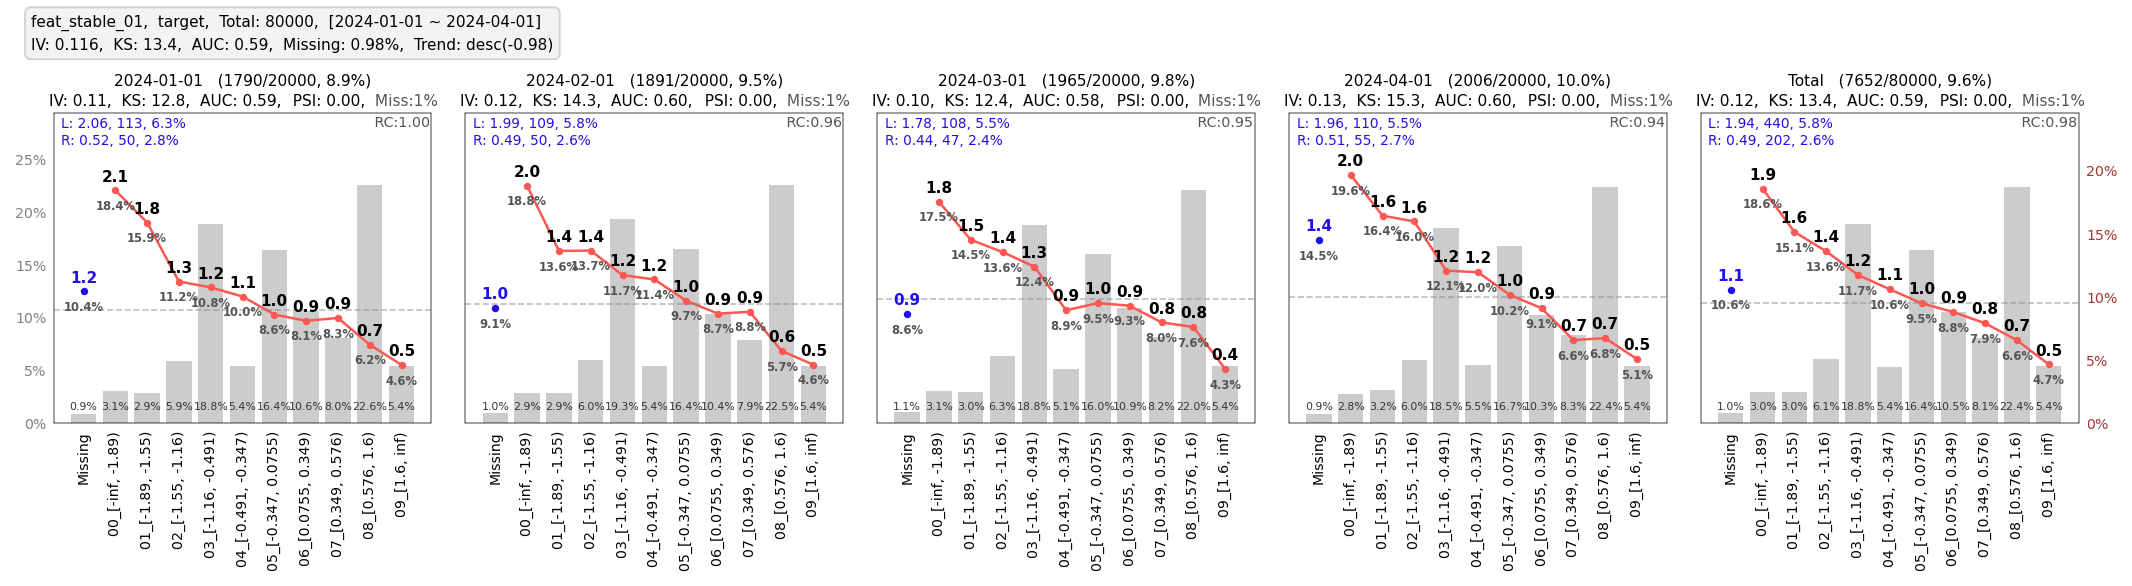

[MARS] 2026-02-02 05:34:12 - INFO - [2/20] Plotting feat_stable_04 (IV=0.0241)...



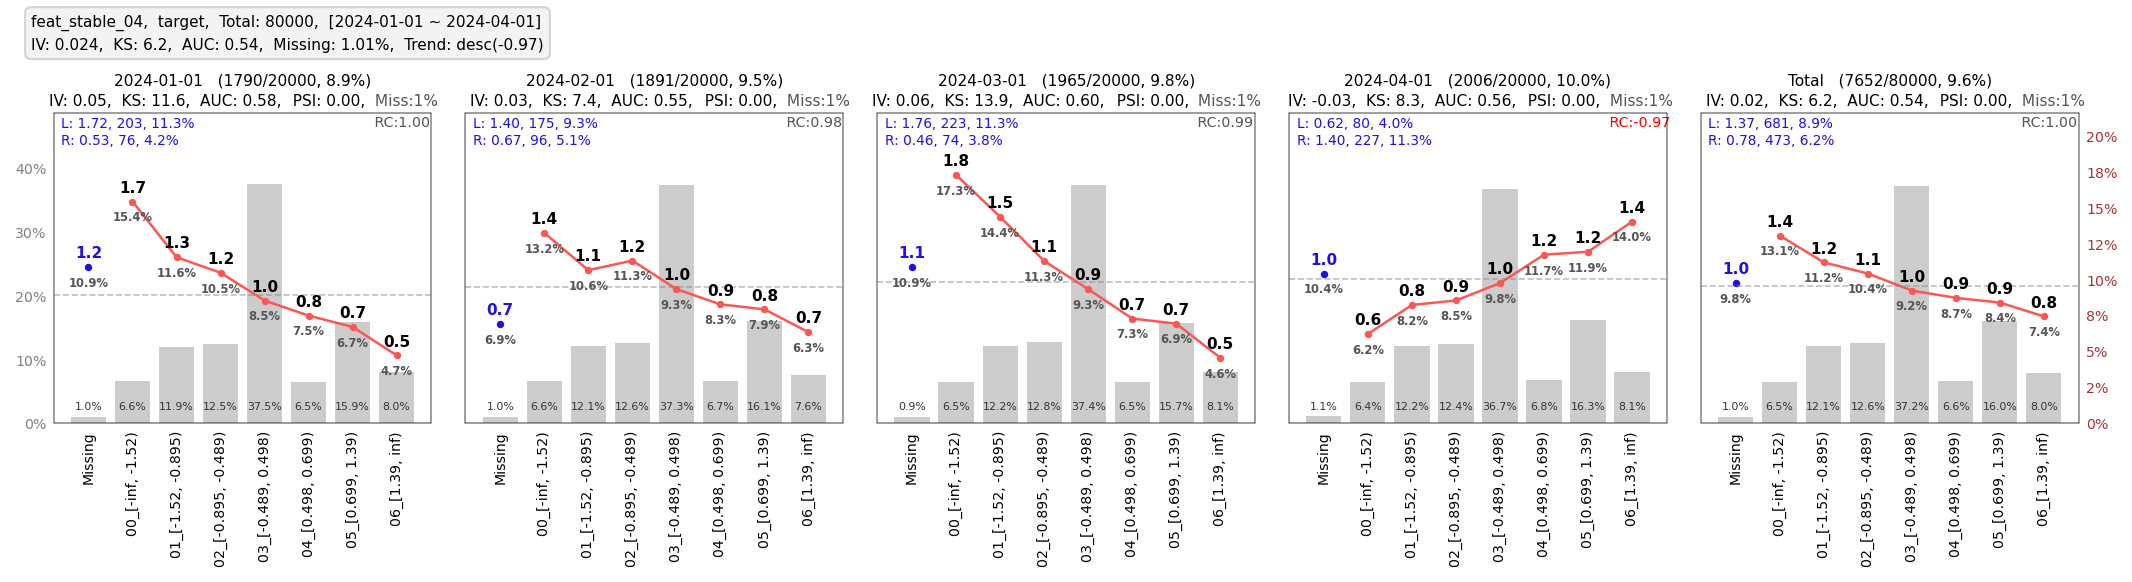

[MARS] 2026-02-02 05:34:13 - INFO - [3/20] Plotting feat_stable_00 (IV=0.0165)...



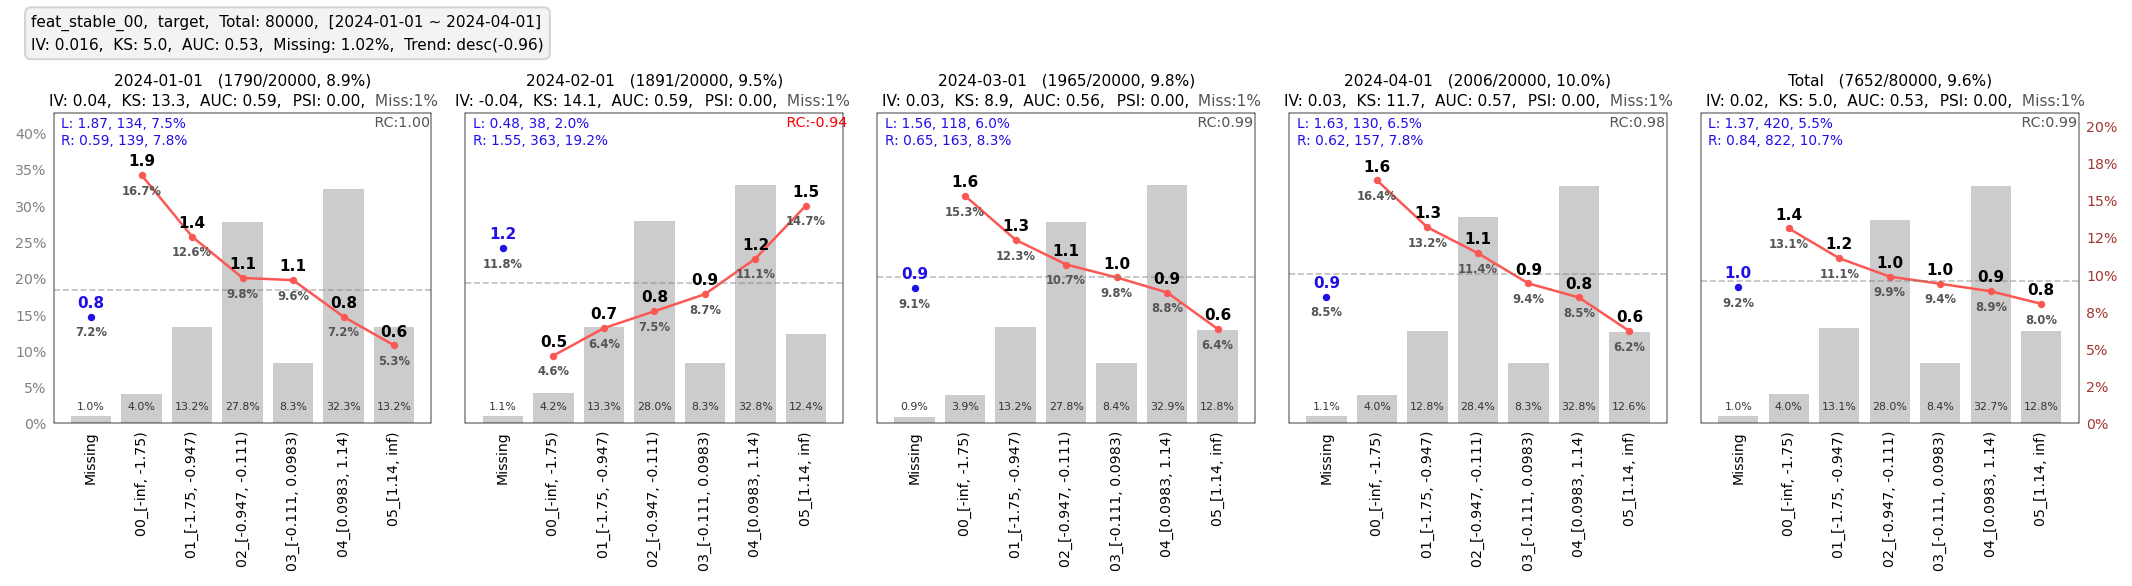

[MARS] 2026-02-02 05:34:13 - INFO - [4/20] Plotting feat_miss_01 (IV=0.0134)...



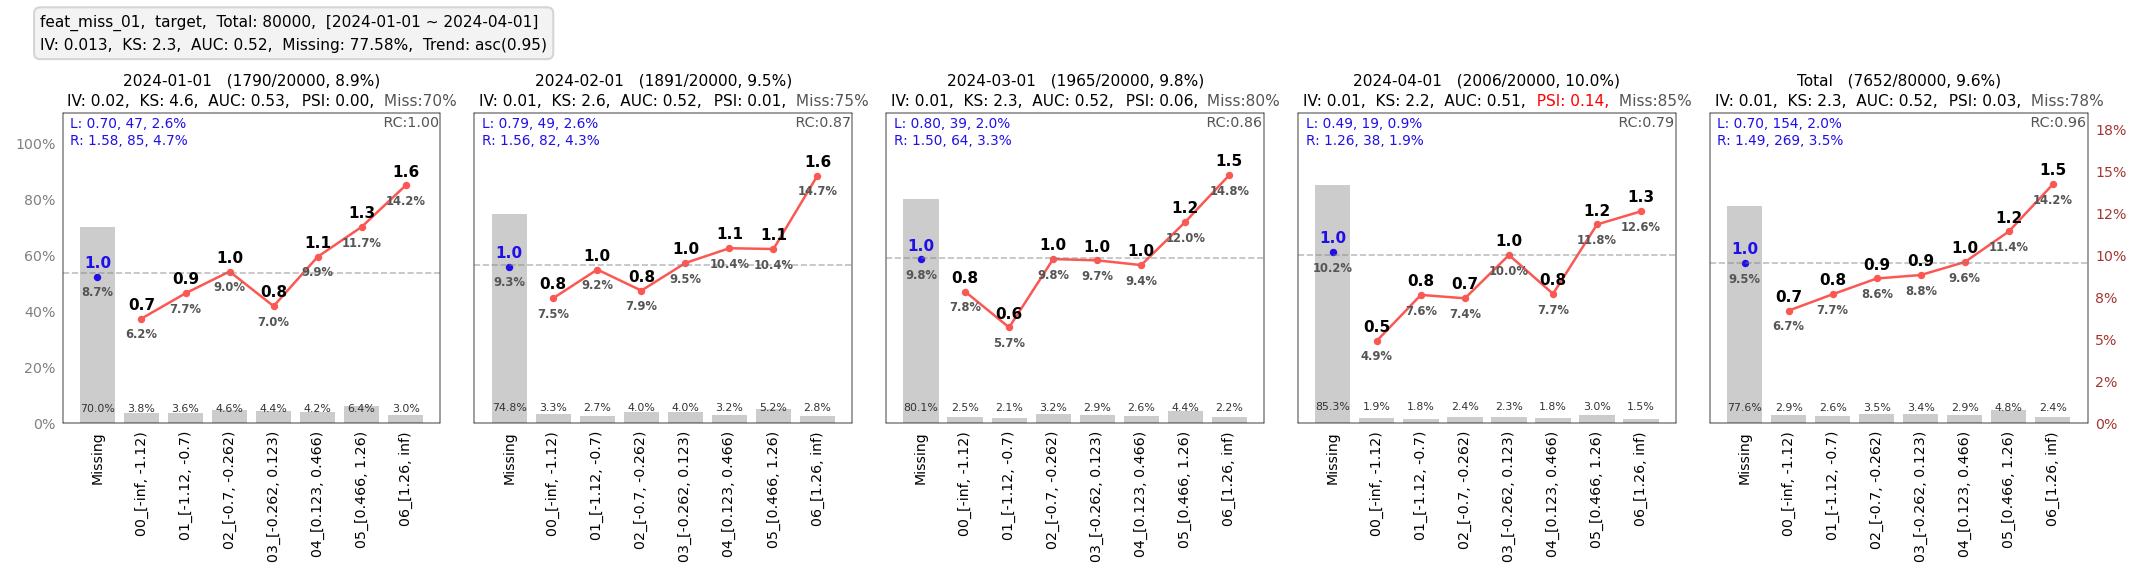

[MARS] 2026-02-02 05:34:13 - INFO - [5/20] Plotting feat_miss_02 (IV=0.0131)...



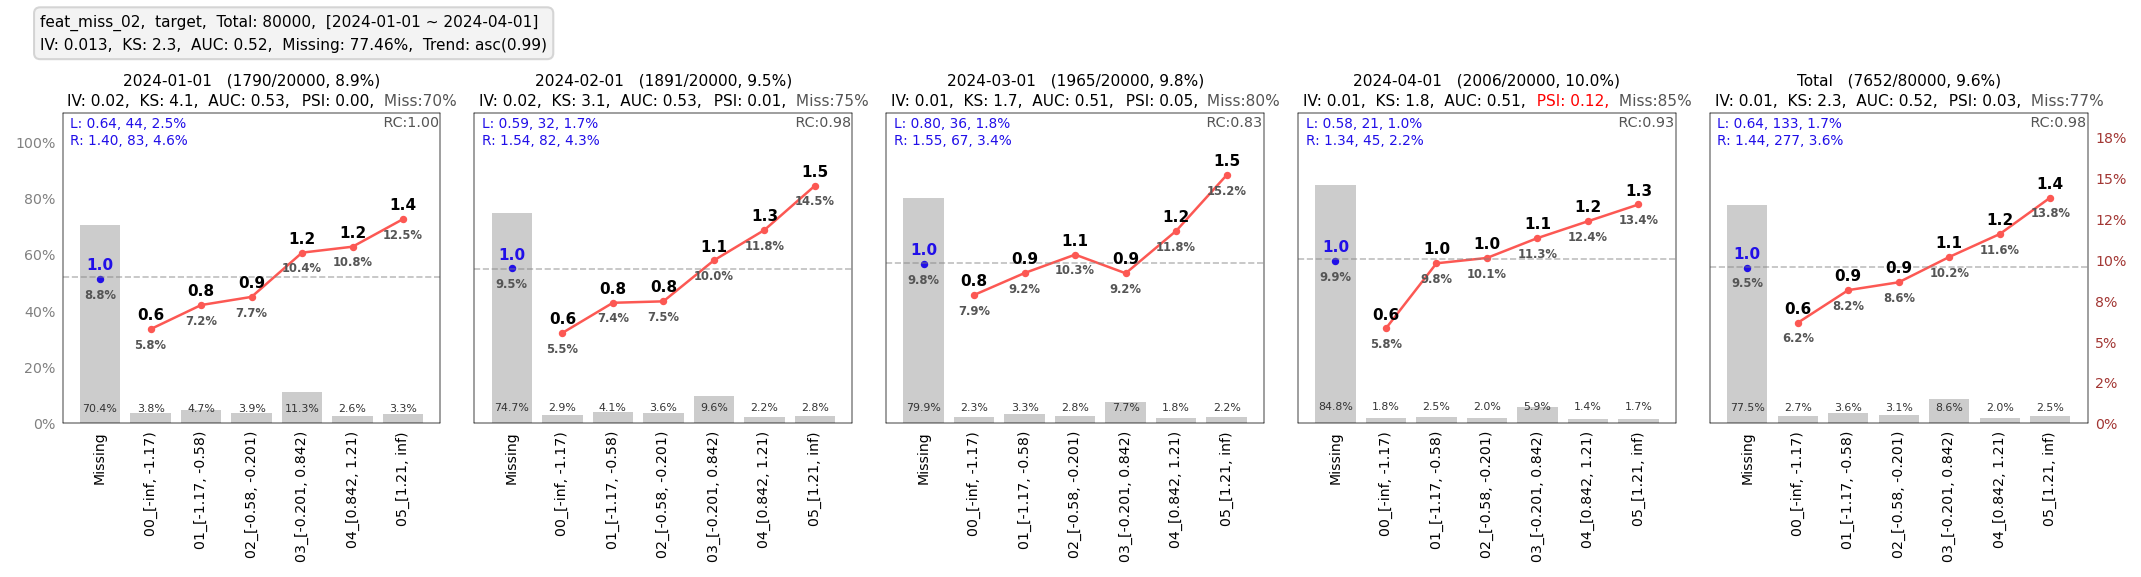

[MARS] 2026-02-02 05:34:14 - INFO - [6/20] Plotting feat_drift_00 (IV=0.0120)...



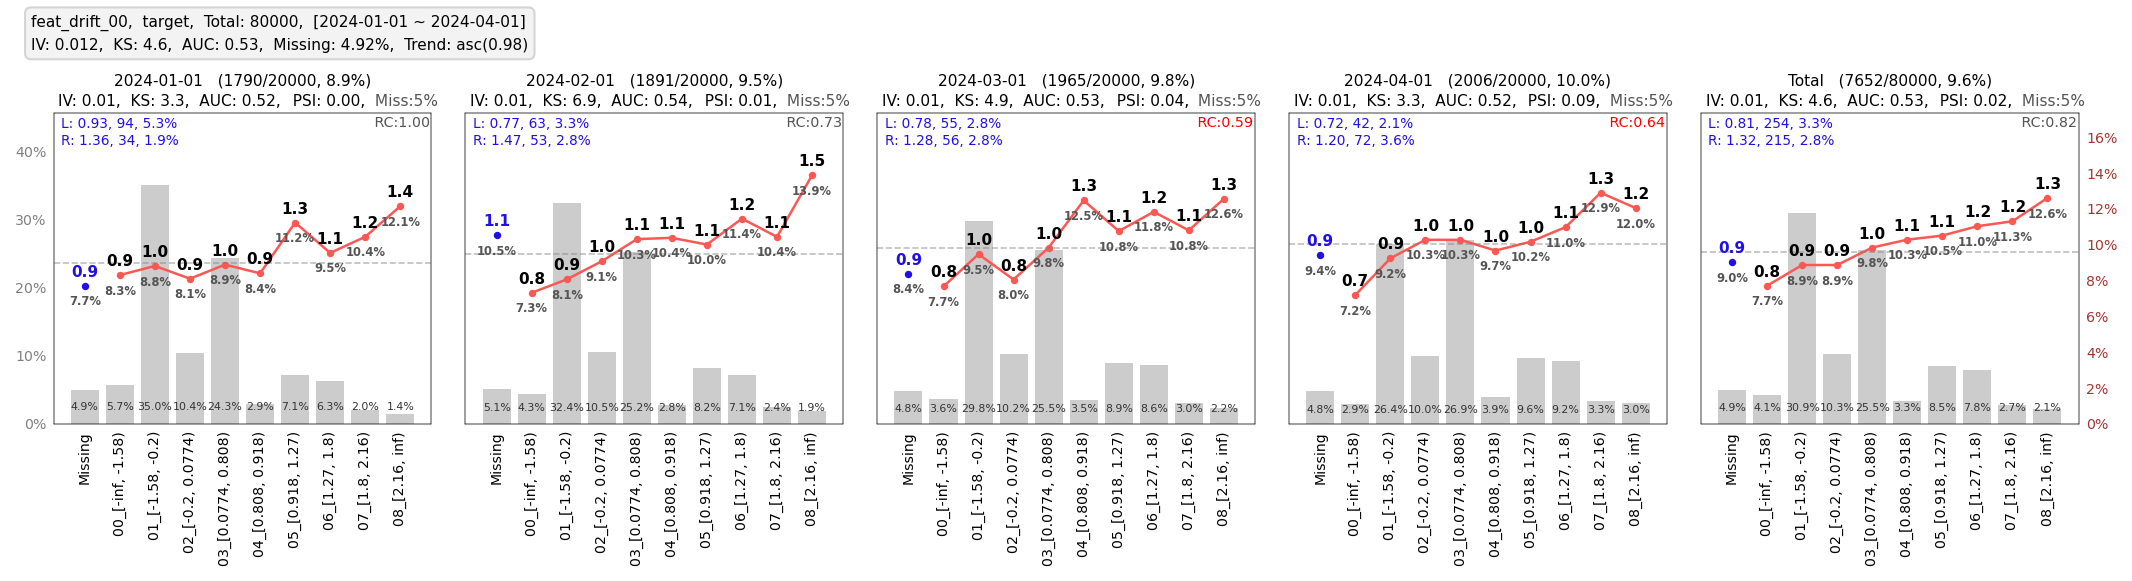

[MARS] 2026-02-02 05:34:14 - INFO - [7/20] Plotting feat_drift_04 (IV=0.0119)...



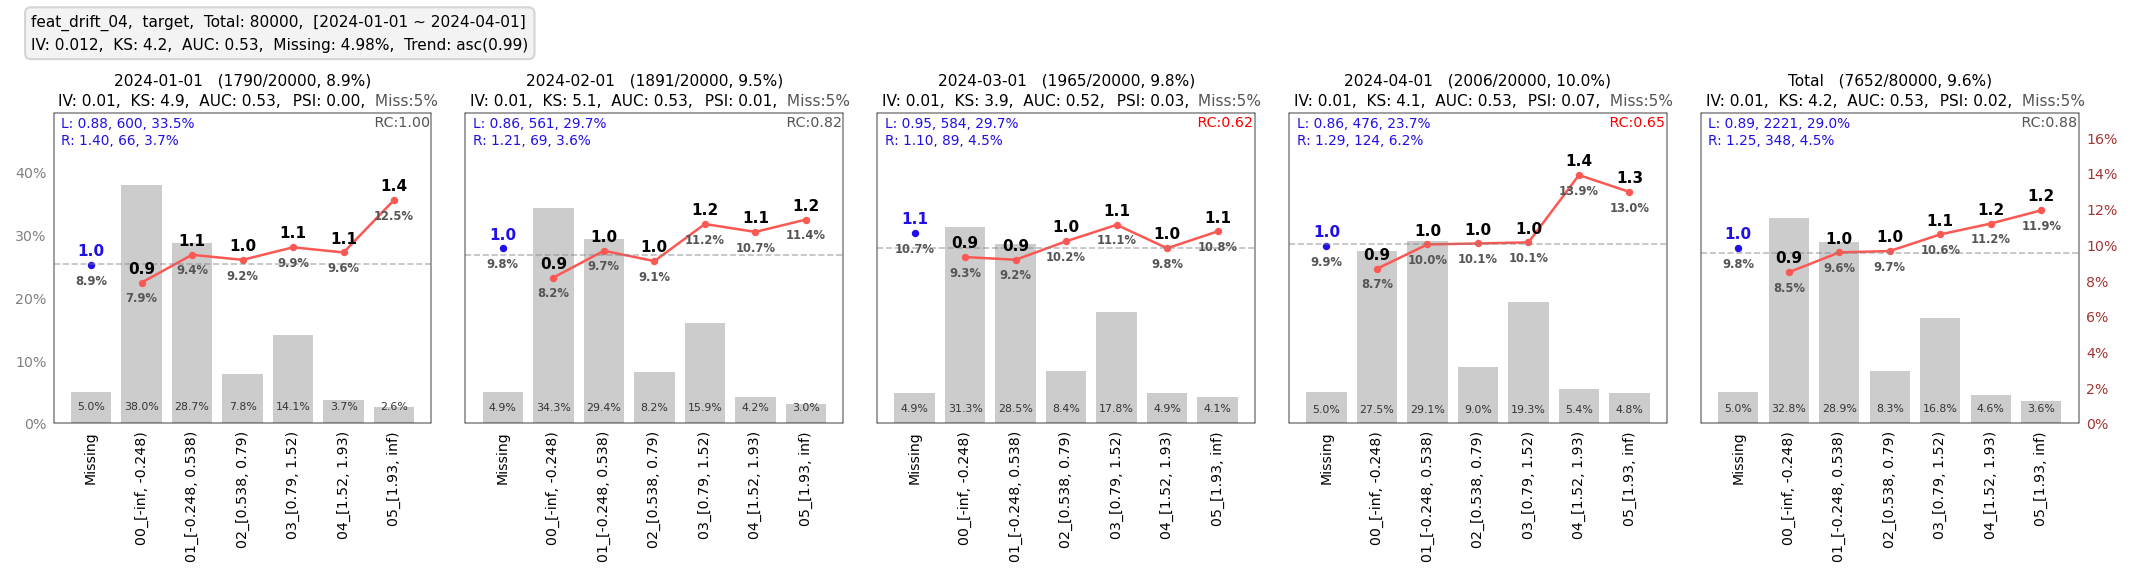

[MARS] 2026-02-02 05:34:15 - INFO - [8/20] Plotting feat_drift_03 (IV=0.0119)...



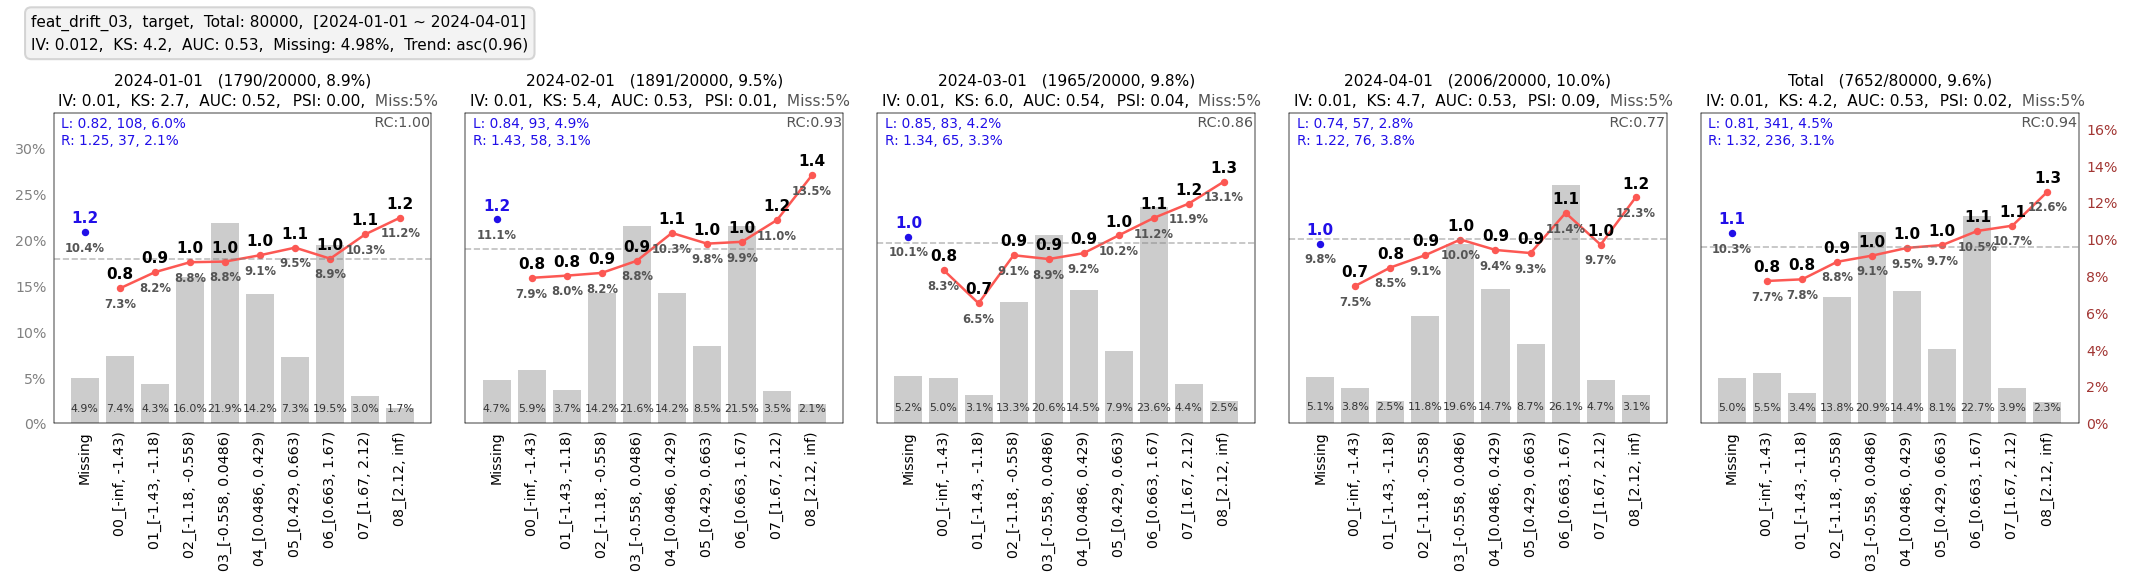

[MARS] 2026-02-02 05:34:15 - INFO - [9/20] Plotting feat_drift_01 (IV=0.0101)...



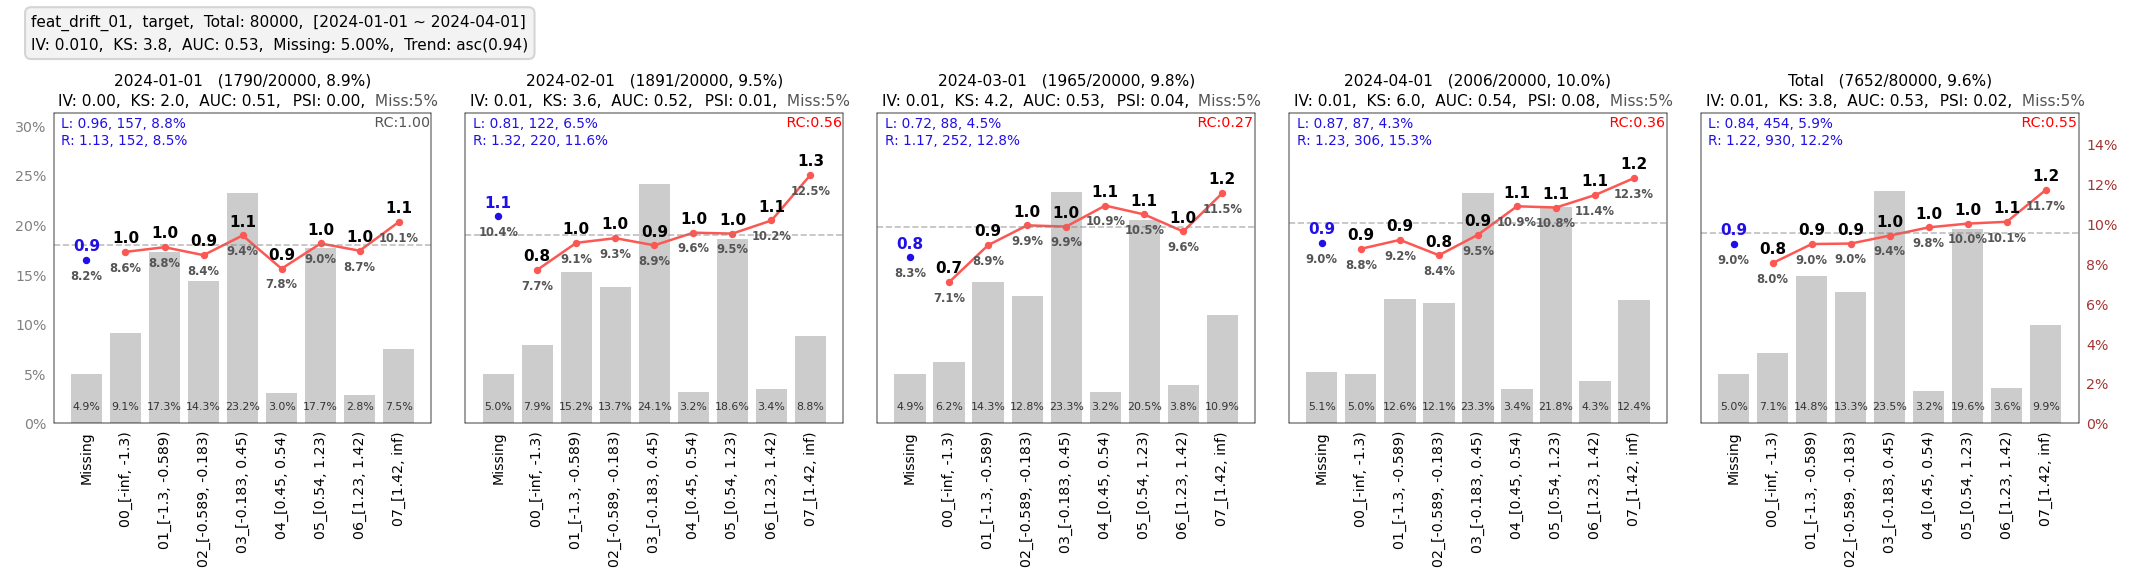

[MARS] 2026-02-02 05:34:16 - INFO - [10/20] Plotting feat_drift_02 (IV=0.0096)...



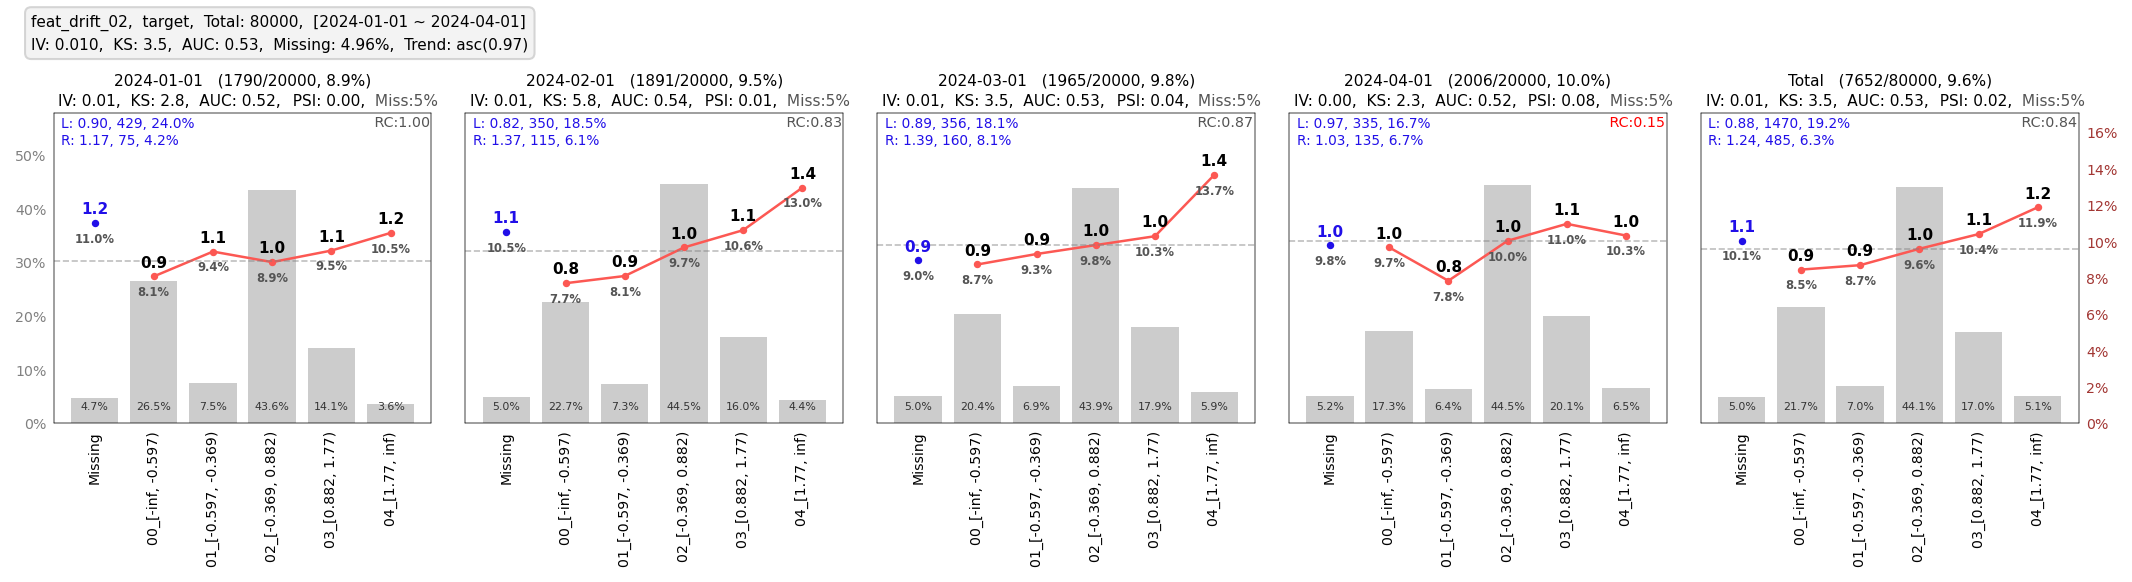

[MARS] 2026-02-02 05:34:16 - INFO - [11/20] Plotting feat_stable_03 (IV=0.0095)...



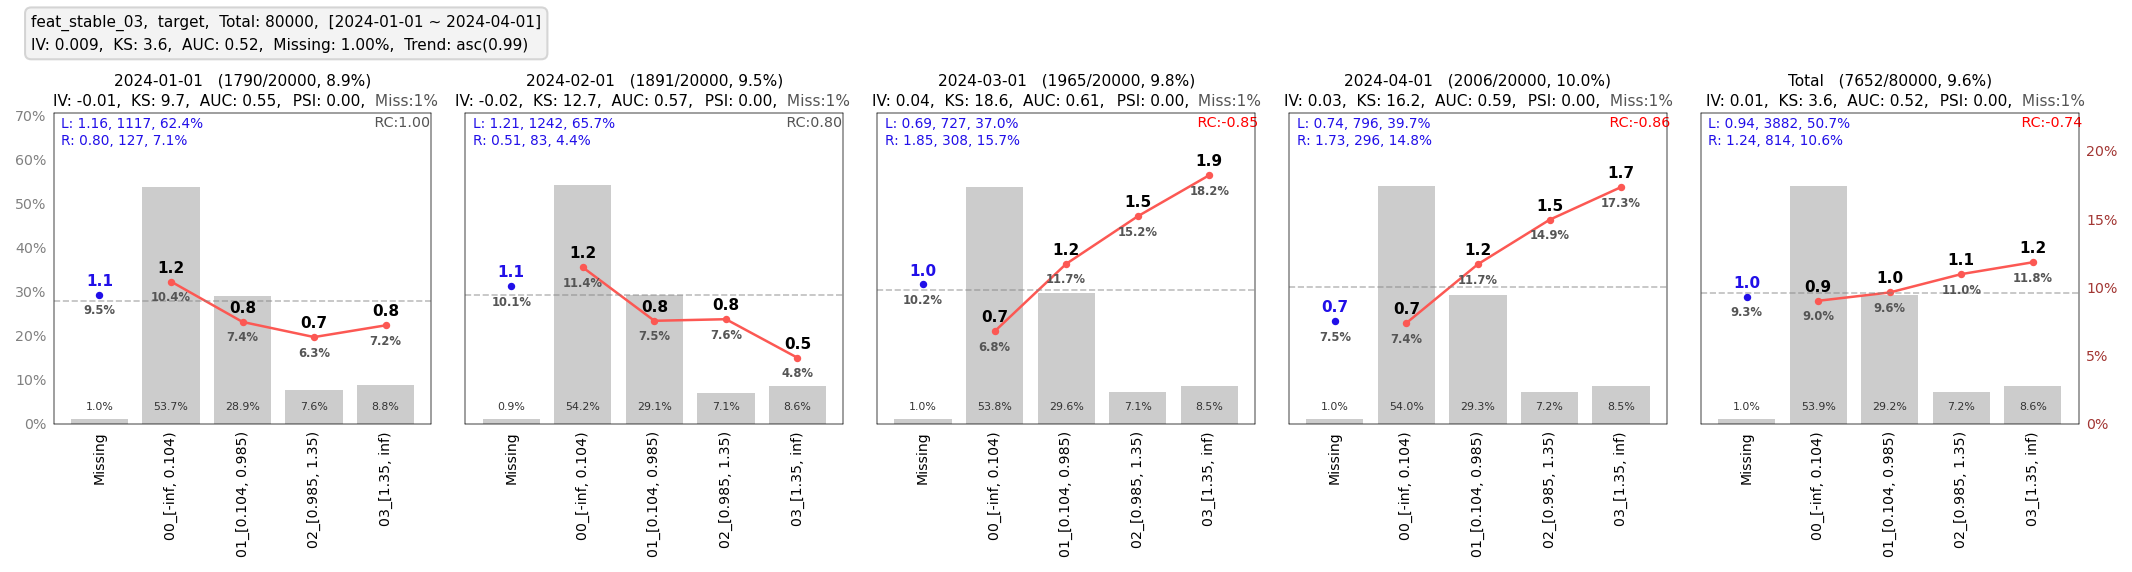

[MARS] 2026-02-02 05:34:16 - INFO - [12/20] Plotting feat_miss_00 (IV=0.0085)...



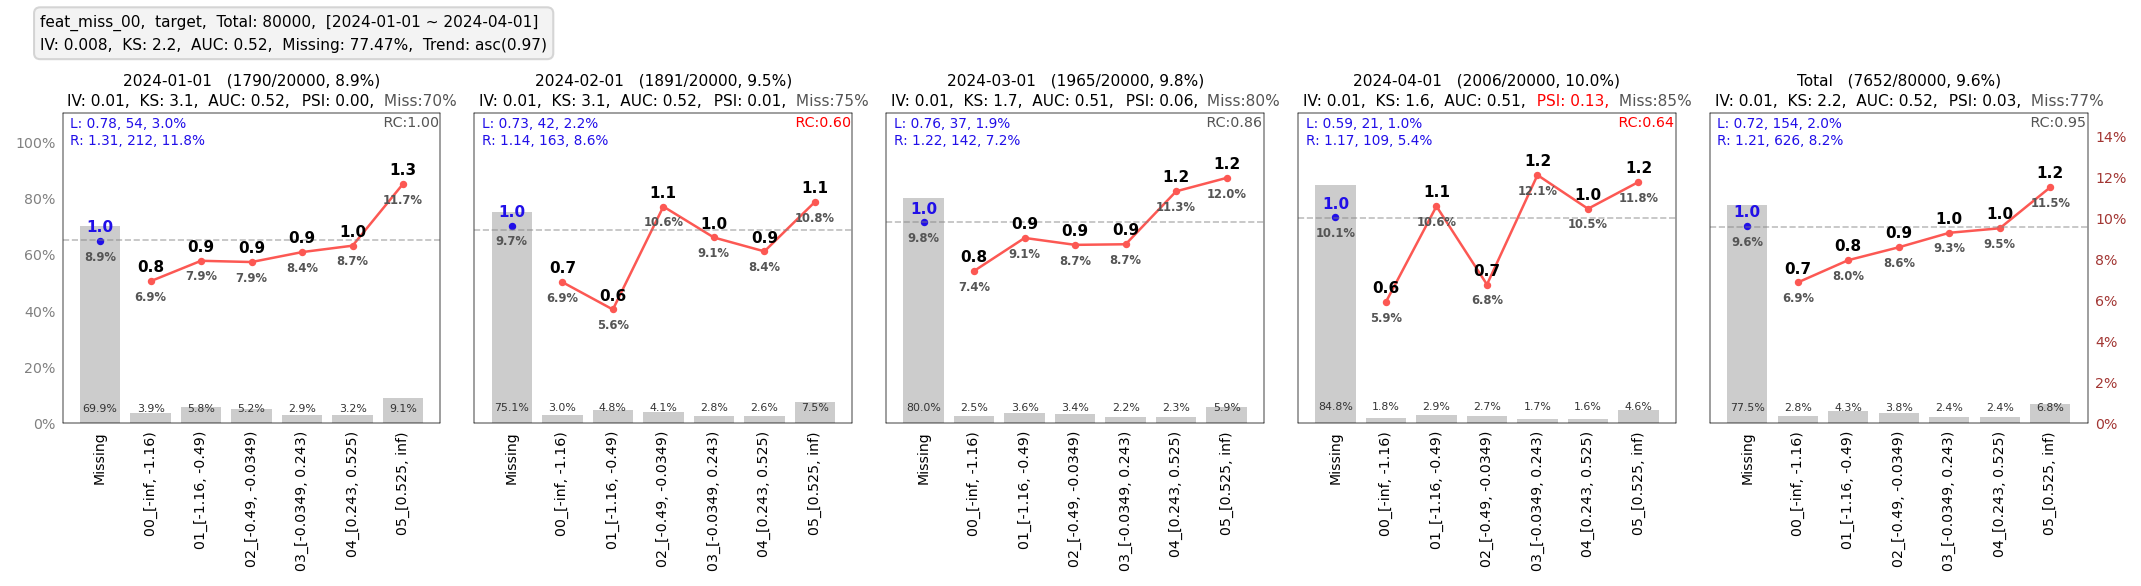

[MARS] 2026-02-02 05:34:17 - INFO - [13/20] Plotting feat_miss_04 (IV=0.0068)...



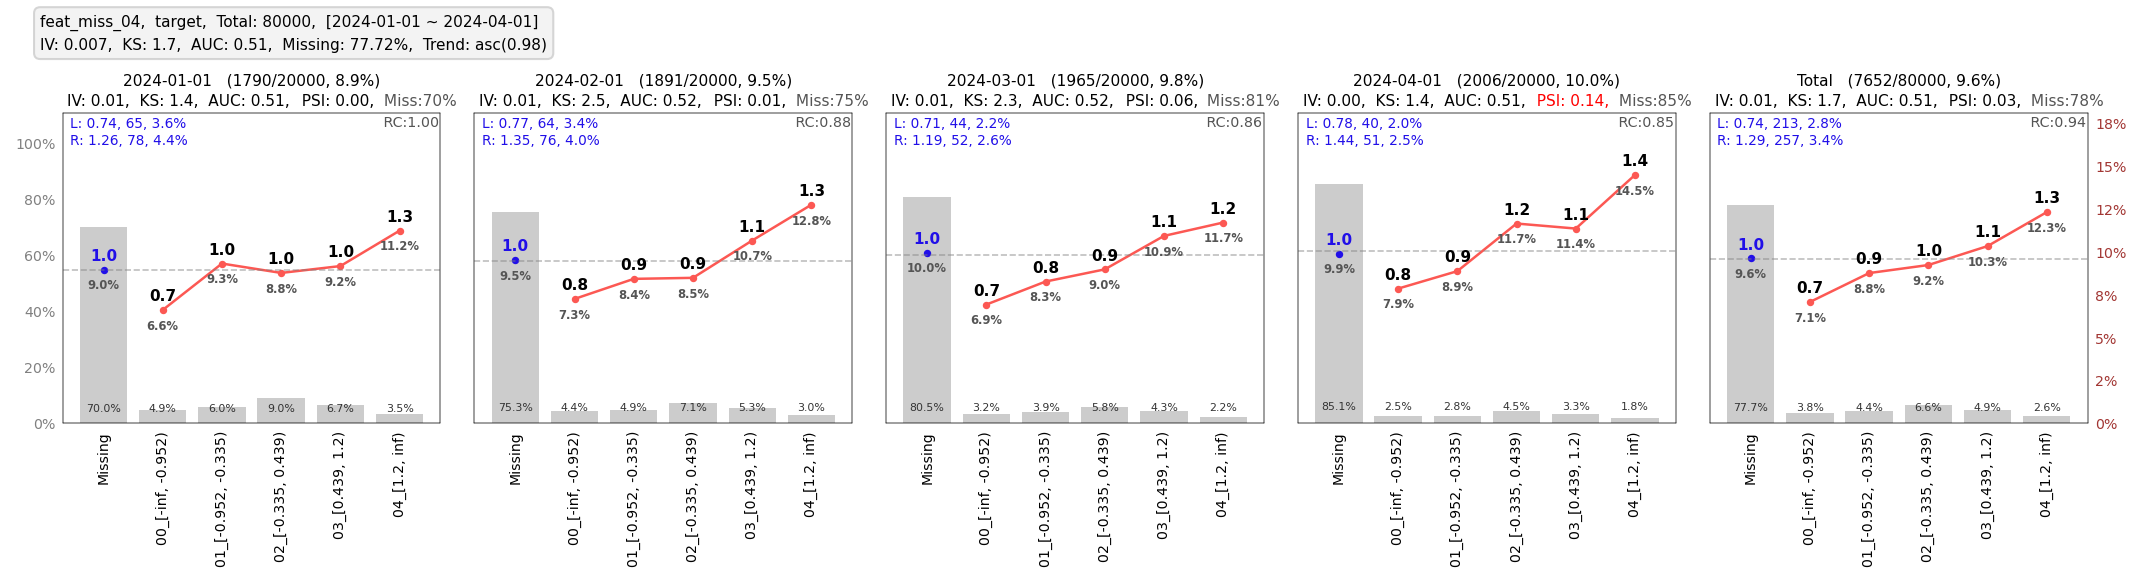

[MARS] 2026-02-02 05:34:17 - INFO - [14/20] Plotting feat_miss_03 (IV=0.0061)...



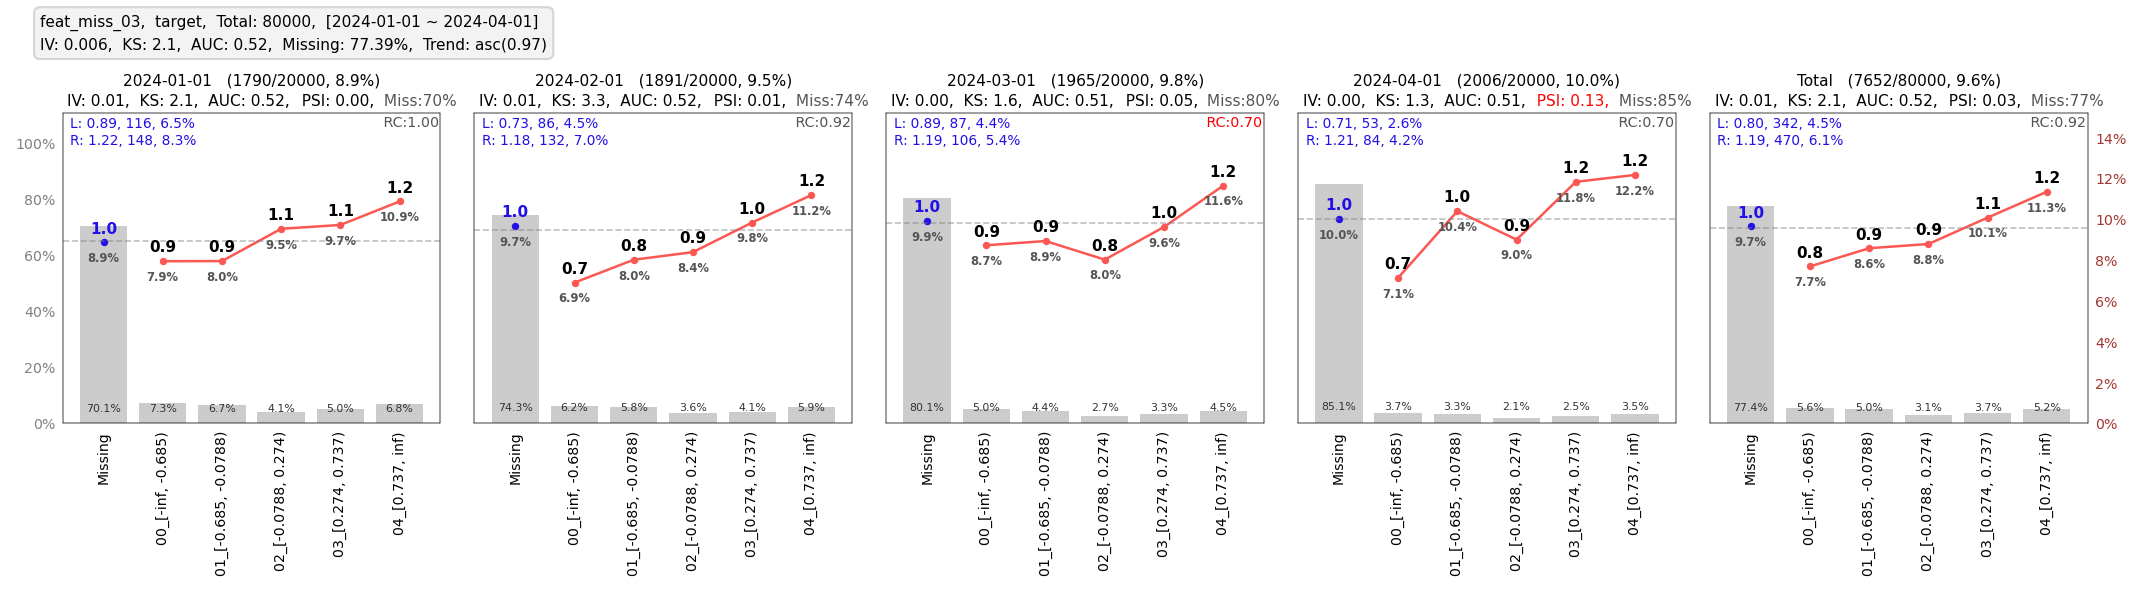

[MARS] 2026-02-02 05:34:18 - INFO - [15/20] Plotting feat_stable_02 (IV=0.0027)...



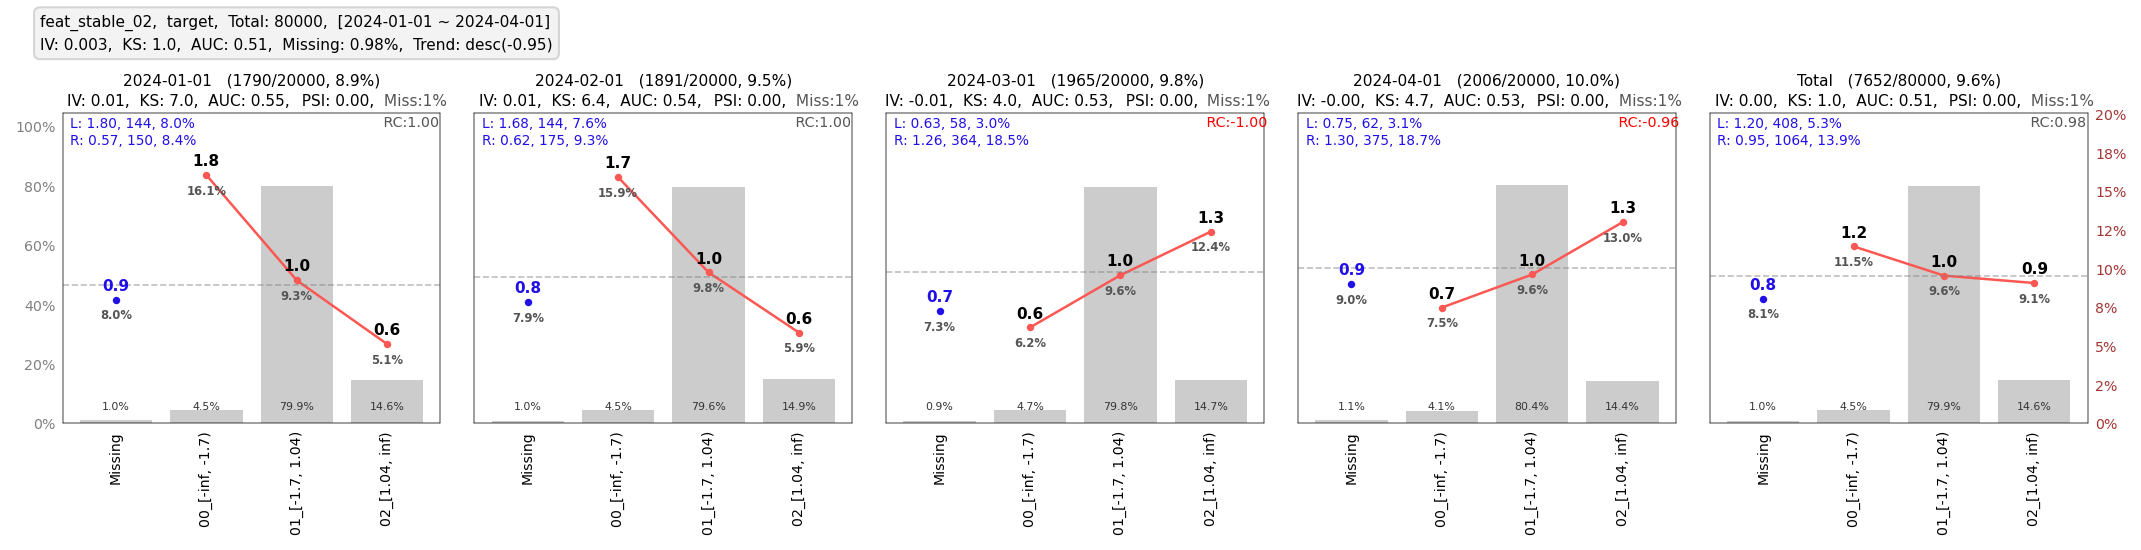

[MARS] 2026-02-02 05:34:18 - INFO - [16/20] Plotting feat_noise_00 (IV=0.0014)...



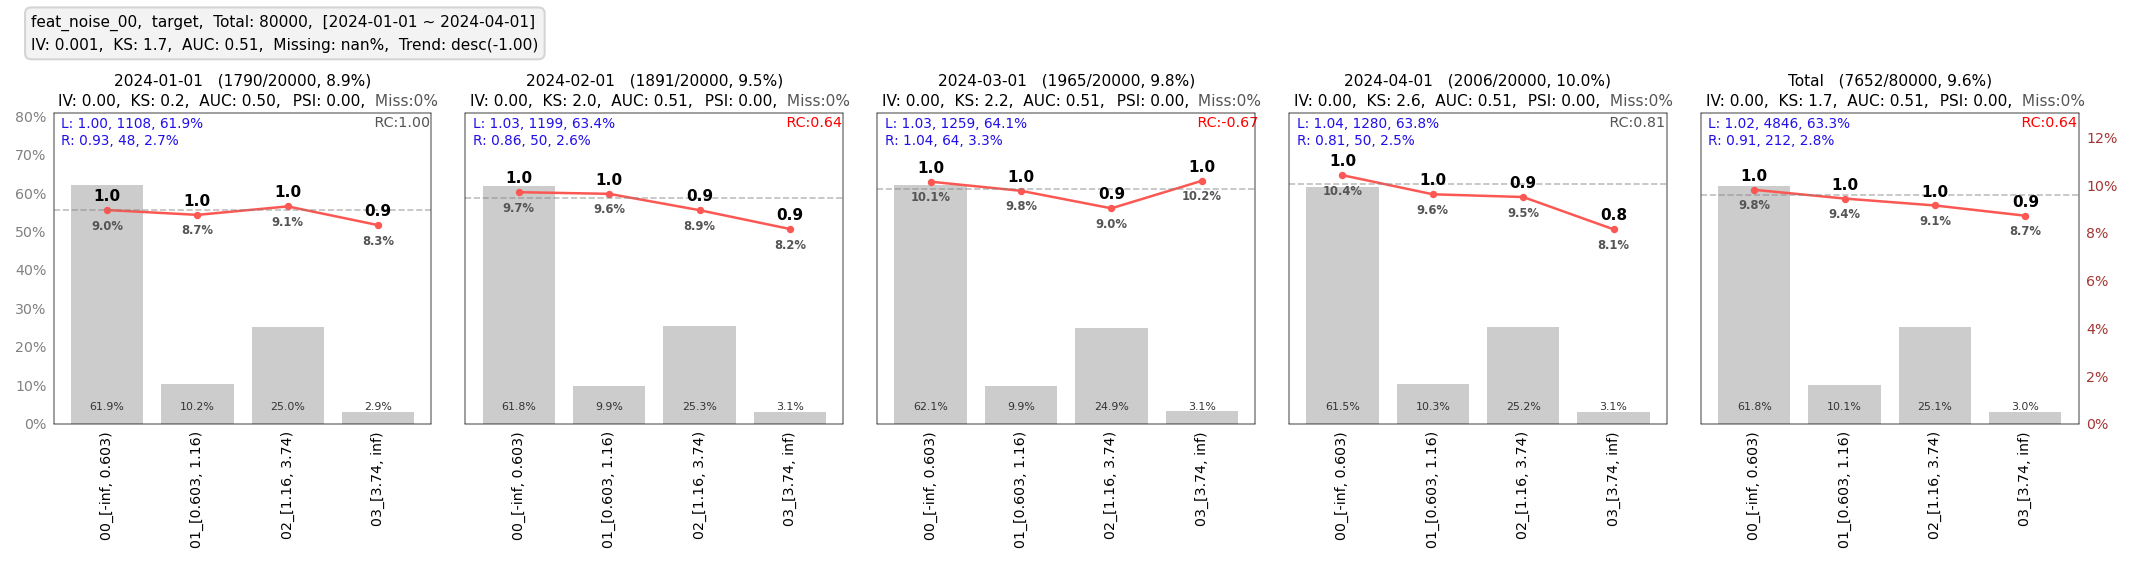

[MARS] 2026-02-02 05:34:18 - INFO - [17/20] Plotting feat_noise_03 (IV=0.0010)...



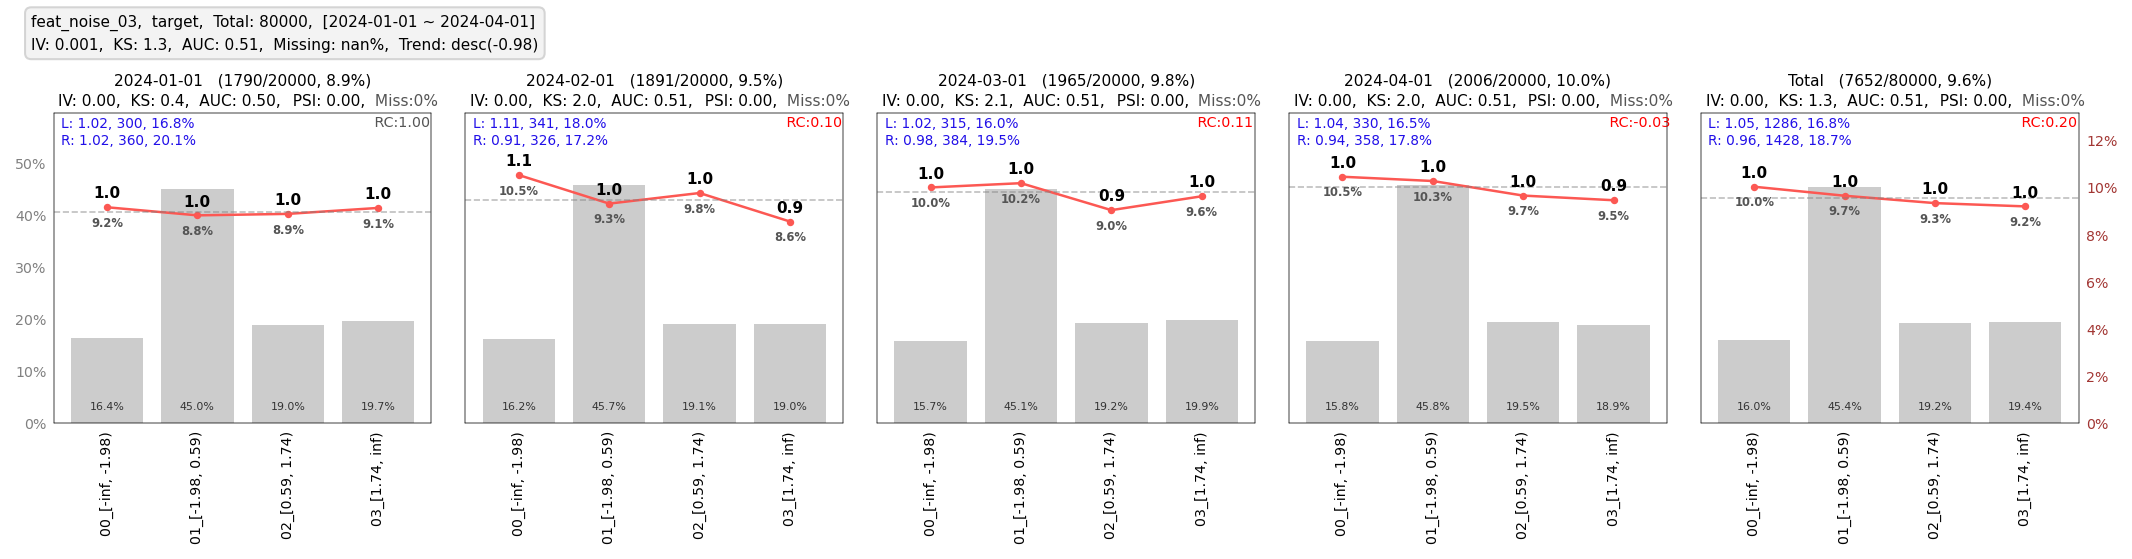

[MARS] 2026-02-02 05:34:19 - INFO - [18/20] Plotting feat_noise_01 (IV=0.0003)...



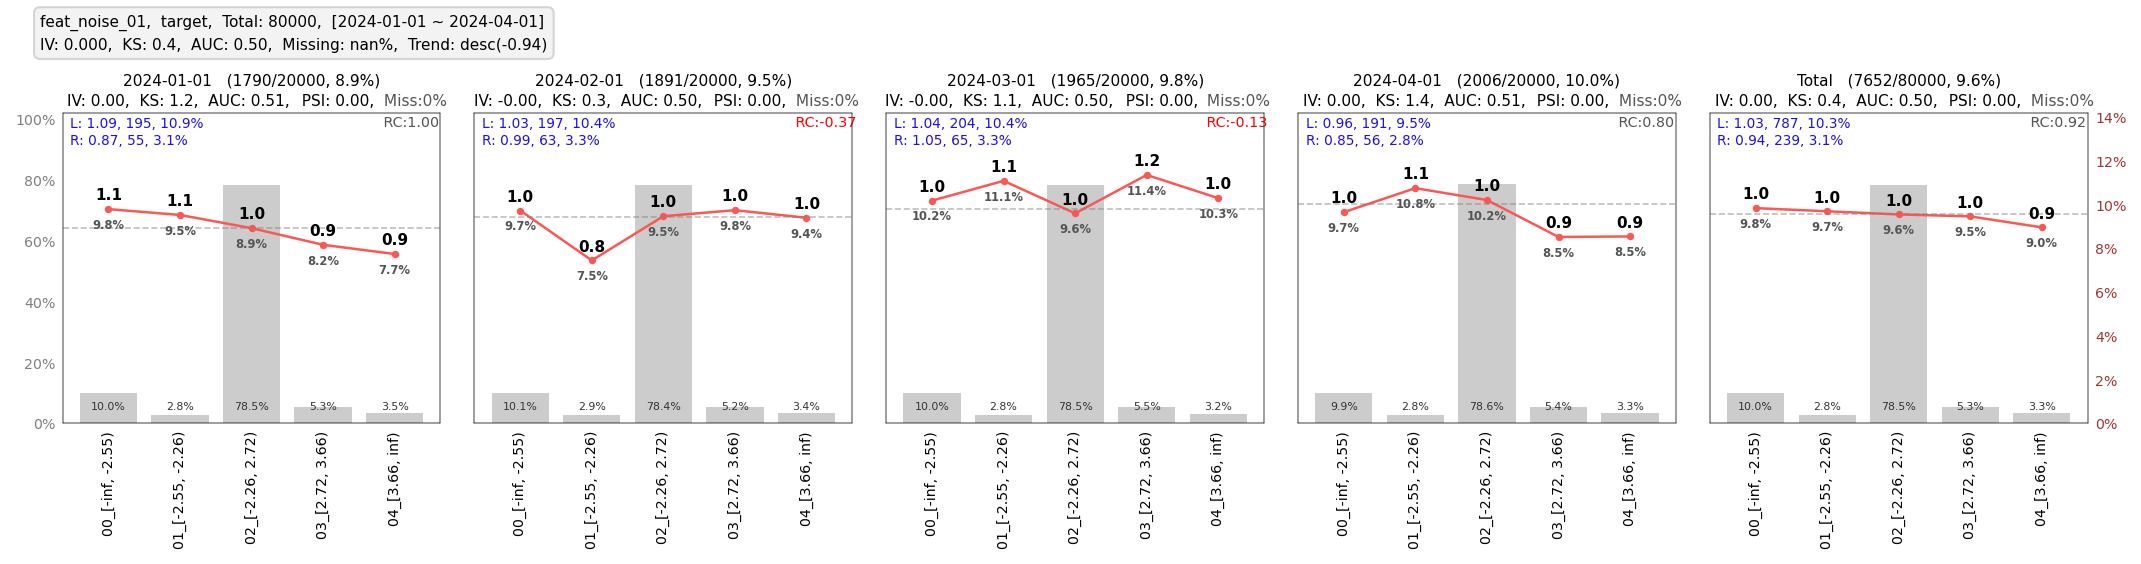

[MARS] 2026-02-02 05:34:19 - INFO - [19/20] Plotting feat_noise_02 (IV=0.0002)...



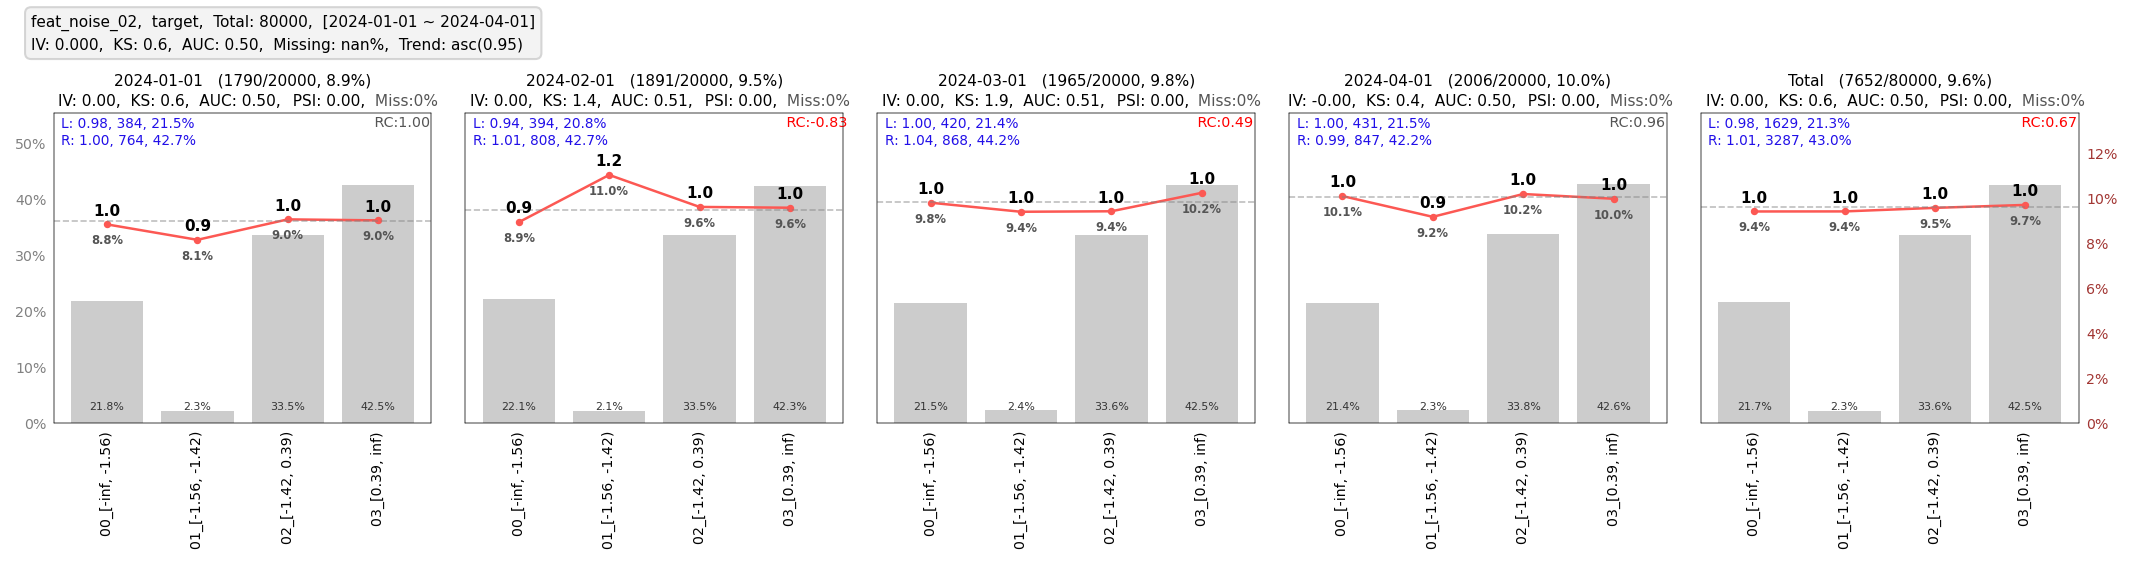

[MARS] 2026-02-02 05:34:19 - INFO - [20/20] Plotting feat_noise_04 (IV=0.0000)...



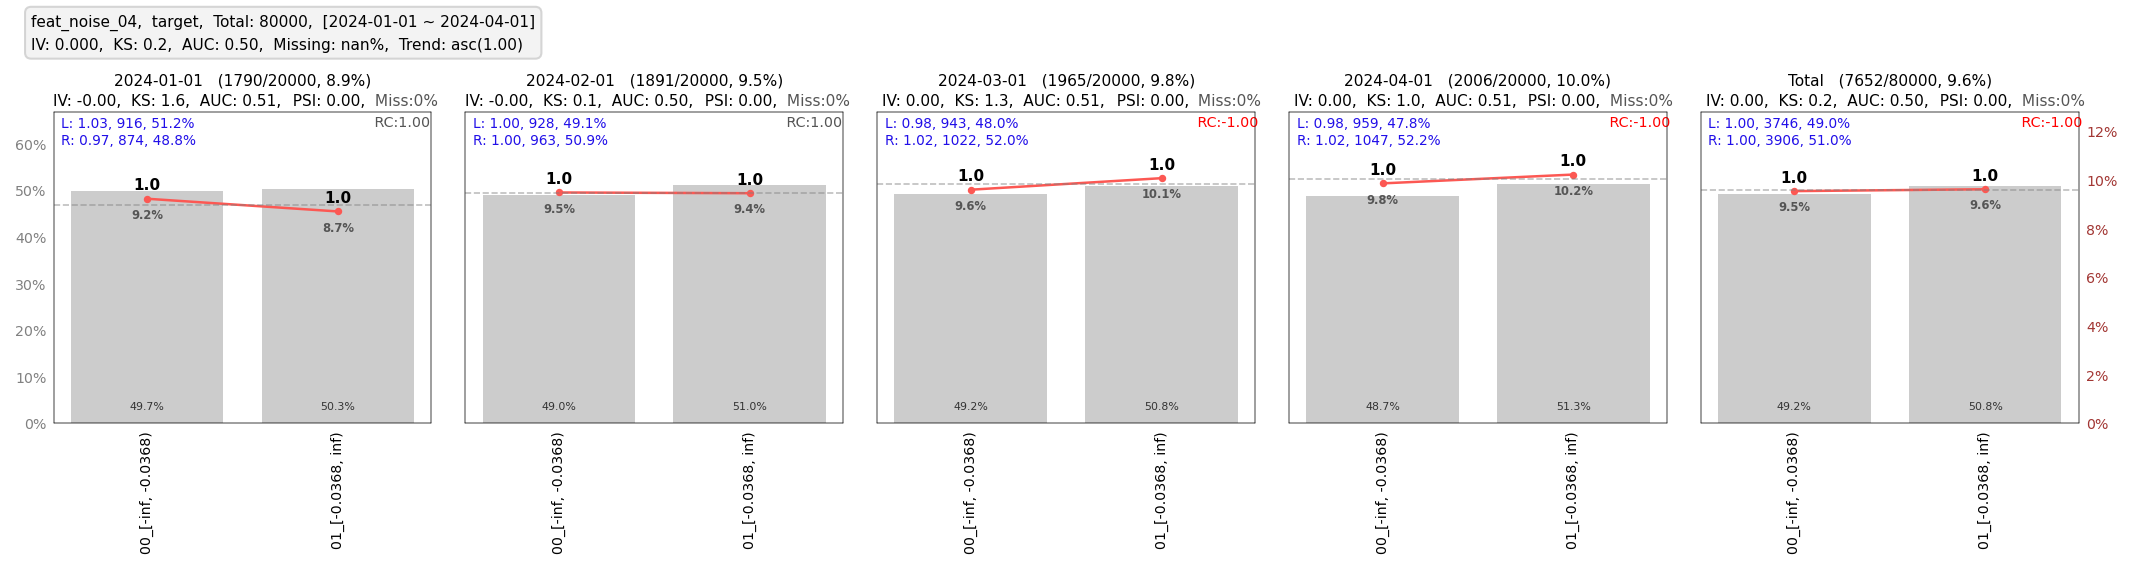

[MARS] 2026-02-02 05:34:20 - INFO - ✅ Batch plotting completed.


In [32]:
set_log_level("INFO")
test_evaluator.plot_feature_binning_risk_trends(
    test_evaluator_report,
    features=features,
    sort_by="iv",
    dpi=150
)